In [1]:
import uproot
import numpy as np
import matplotlib.pylab as plt
import matplotlib.colors as colors
import scipy
from scipy.optimize import curve_fit # https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html
from scipy import stats
import ROOT
import zfit
import mplhep
from hepstats.splot import compute_sweights
path = '' # set this to '' to run on the GitHub version
events_sim = uproot.open(path+'PhaseSpaceSimulation.root')
events_down = uproot.open(path+'B2HHH_MagnetDown.root')
events_up = uproot.open(path+'B2HHH_MagnetUp.root')

/Users/damianfrench/miniconda3/envs/root_env/lib/python3.10/site-packages/zfit/__init__.py:93: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
def perpendicular_distance(point, start, end):
    """Compute distance from a point to a line defined by start and end."""
    line_vec = end - start
    point_vec = point - start
    line_len = np.linalg.norm(line_vec)
    if line_len == 0:
        return np.linalg.norm(point_vec)
    # Project point onto line
    proj_len = np.dot(point_vec, line_vec) / line_len
    proj_point = start + (proj_len / line_len) * line_vec
    return np.linalg.norm(point - proj_point)
def Selection_Alg(original_probabilties,plotting=False):
    original_probabilties = np.array(original_probabilties)
    probabilties = np.array(original_probabilties)
    mask = probabilties > 0
    probabilties = probabilties[mask]
   
    delta_nll = np.log(probabilties) - np.log(1-probabilties)
    cuts = np.linspace(delta_nll.min(), delta_nll.max(), 500)
    purity = []
    yield_ = []
    for c in cuts:
        mask = delta_nll > c                # select tracks above cut
        selected_K = probabilties[mask].sum()       # expected kaon yield
        n_selected = mask.sum()             # total selected tracks

        if n_selected > 0:
            purity.append(selected_K / n_selected)
        else:
            purity.append(0)
        yield_.append(selected_K)
    yield_ = np.array(yield_)
    purity = np.array(purity)
    cuts   = np.array(cuts)
   
    yield_output=yield_
    mask2 = yield_ > 1.0
    yield_  = yield_[mask2]
    purity = purity[mask2]
    cuts   = cuts[mask2]

    # print(yield_[0], purity[0], yield_[len(yield_)-1], purity[len(yield_)-1])
   
    distances = np.array([perpendicular_distance(np.array([y, p]),  np.array([yield_[0], purity[0]]), np.array([yield_[-1], purity[-1]])) for y, p in zip(yield_, purity)])
    knee_idx = np.argmax(distances)
    knee_cut = cuts[knee_idx]
    knee_yield = yield_[knee_idx]
    knee_purity = purity[knee_idx]
    if plotting:
        print('length',len(delta_nll))
        print(f"Suggested knee ΔNLL cut: {knee_cut:.3f}")
        print(f"Expected yield: {knee_yield:.2f}, Expected purity: {knee_purity:.2f}")
        fig,ax=plt.subplots(2,figsize=(6,5),layout='constrained',sharex=True)
        ax[0].axvline(knee_yield, color='red', linestyle='--', label=f'Cut: {knee_cut:.3f}')
        ax[0].plot(yield_, purity, marker='.', linestyle='',label='Yield-Purity line')
        ax[0].set_ylabel("Expected Sudo-Purity")
        ax[0].legend()
        gradient=(purity[-1]-purity[0])/(yield_[-1]-yield_[0])
        ax[0].plot(yield_,yield_*gradient+1,linestyle='--',color='k',label='linear fit')
        ax[1].plot(yield_,distances,label='normalised d from linear')
        ax[1].axvline(knee_yield, color='red', linestyle='--', label=f'Cut: {knee_cut:.3f}')
        ax[1].set_xlabel("Expected Kaon Sudo-Yield")
        ax[1].set_ylabel("normalised distance from linear fit")
        ax[1].legend(loc='upper left', prop={'size': 8})

        

        plt.show()
    def compute_logit_mask(p, knee_cut):
        valid = (p > 0.0) & (p < 1.0)
        logit = np.where(valid, np.log(p / (1.0 - p)), np.nan)
        mask = valid & (logit > knee_cut)
        return logit, mask
    

    logit, output_mask = compute_logit_mask(p=original_probabilties,knee_cut=knee_cut)
    # print(output_mask)
    return output_mask, knee_cut
def Selection_Alg1(prob_k, prob_pi, cut_k, cut_pi,plotting=False):
    return (prob_k>cut_k) & (prob_pi>cut_pi)

In [3]:
def calculating_neutral_particle_invariant_mass(data,suffix1,suffix2,m_k):
    E1=np.sqrt(data[f'{suffix1}_PX']**2+data[f'{suffix1}_PY']**2+data[f'{suffix1}_PZ']**2+m_k**2)
    E2=np.sqrt(data[f'{suffix2}_PX']**2+data[f'{suffix2}_PY']**2+data[f'{suffix2}_PZ']**2+m_k**2)
    # p=data[f'{suffix1}_PX']*data[f'{suffix2}_PX']+data[f'{suffix1}_PY']*data[f'{suffix2}_PY']+data[f'{suffix1}_PZ']*data[f'{suffix2}_PZ']
    px=data[f'{suffix1}_PX']+data[f'{suffix2}_PX']
    py=data[f'{suffix1}_PY']+data[f'{suffix2}_PY']
    pz=data[f'{suffix1}_PZ']+data[f'{suffix2}_PZ']
    return np.sqrt((E1+E2)**2-(px**2+py**2+pz**2))   
def B_meson_invariant_mass(data,m_k,mask1,mask2,mask3):
    E1=np.sqrt(data['H1_PX']**2+data['H1_PY']**2+data['H1_PZ']**2+m_k**2)
    E2=np.sqrt(data['H2_PX']**2+data['H2_PY']**2+data['H2_PZ']**2+m_k**2)
    E3=np.sqrt(data['H3_PX']**2+data['H3_PY']**2+data['H3_PZ']**2+m_k**2)
    p12=data['H1_PX']*data['H2_PX']+data['H1_PY']*data['H2_PY']+data['H1_PZ']*data['H2_PZ']
    p13=data['H1_PX']*data['H3_PX']+data['H1_PY']*data['H3_PY']+data['H1_PZ']*data['H3_PZ']
    p23=data['H2_PX']*data['H3_PX']+data['H2_PY']*data['H3_PY']+data['H2_PZ']*data['H3_PZ']
    second_term=(E1*E2)-p12+(E1*E3)-p13+(E2*E3)-p23
    m_B_squared=3*m_k**2+2*second_term
    m_B=np.sqrt(m_B_squared)[mask1 & mask2 & mask3]
    return m_B
def p_percentage_uncertainty(t):
    if t in ['x','y']:
        return np.sqrt(2)*(1*10**-3)
    else:
        return (1*10**-3)
def mass_uncertainties_B(m_k, data, m_B, mask1, mask2, mask3):

    combined_mask = mask1 & mask2 & mask3

    # --- Masked momenta ---
    px1 = data['H1_PX'][combined_mask]
    py1 = data['H1_PY'][combined_mask]
    pz1 = data['H1_PZ'][combined_mask]

    px2 = data['H2_PX'][combined_mask]
    py2 = data['H2_PY'][combined_mask]
    pz2 = data['H2_PZ'][combined_mask]

    px3 = data['H3_PX'][combined_mask]
    py3 = data['H3_PY'][combined_mask]
    pz3 = data['H3_PZ'][combined_mask]

    m_B = m_B  # already masked in B_meson_invariant_mass

    # --- Energies (masked) ---
    E1 = np.sqrt(px1**2 + py1**2 + pz1**2 + m_k**2)
    E2 = np.sqrt(px2**2 + py2**2 + pz2**2 + m_k**2)
    E3 = np.sqrt(px3**2 + py3**2 + pz3**2 + m_k**2)

    E_tot = E1 + E2 + E3

    # --- Total momentum (masked) ---
    Px_tot = px1 + px2 + px3
    Py_tot = py1 + py2 + py3
    Pz_tot = pz1 + pz2 + pz3

    # --- Momentum uncertainties ---
    eps_x = p_percentage_uncertainty('x')
    eps_y = p_percentage_uncertainty('y')
    eps_z = p_percentage_uncertainty('z')

    sigma = 0

    for px, py, pz, Ei in [(px1, py1, pz1, E1),
                           (px2, py2, pz2, E2),
                           (px3, py3, pz3, E3)]:

        sigma_px = px * eps_x
        sigma_py = py * eps_y
        sigma_pz = pz * eps_z

        dmdpx = (E_tot/Ei * px - Px_tot) / m_B
        dmdpy = (E_tot/Ei * py - Py_tot) / m_B
        dmdpz = (E_tot/Ei * pz - Pz_tot) / m_B

        sigma += (dmdpx**2) * sigma_px**2
        sigma += (dmdpy**2) * sigma_py**2
        sigma += (dmdpz**2) * sigma_pz**2

    return np.sqrt(sigma)
def neutral_mass_uncertainty(data, suffix1, suffix2, m_k, mask):

    px1 = data[f'{suffix1}_PX'][mask]
    py1 = data[f'{suffix1}_PY'][mask]
    pz1 = data[f'{suffix1}_PZ'][mask]

    px2 = data[f'{suffix2}_PX'][mask]
    py2 = data[f'{suffix2}_PY'][mask]
    pz2 = data[f'{suffix2}_PZ'][mask]

    E1 = np.sqrt(px1**2 + py1**2 + pz1**2 + m_k**2)
    E2 = np.sqrt(px2**2 + py2**2 + pz2**2 + m_k**2)

    E_tot = E1 + E2

    Px_tot = px1 + px2
    Py_tot = py1 + py2
    Pz_tot = pz1 + pz2

    m_sq = E_tot**2 - (Px_tot**2 + Py_tot**2 + Pz_tot**2)
    m = np.sqrt(m_sq)

    eps_x = p_percentage_uncertainty('x')
    eps_y = p_percentage_uncertainty('y')
    eps_z = p_percentage_uncertainty('z')

    sigma = 0

    for px, py, pz, Ei in [(px1, py1, pz1, E1),
                           (px2, py2, pz2, E2)]:

        sigma_px = px * eps_x
        sigma_py = py * eps_y
        sigma_pz = pz * eps_z

        dmdpx = (E_tot/Ei * px - Px_tot) / m
        dmdpy = (E_tot/Ei * py - Py_tot) / m
        dmdpz = (E_tot/Ei * pz - Pz_tot) / m

        sigma += (dmdpx**2) * sigma_px**2
        sigma += (dmdpy**2) * sigma_py**2
        sigma += (dmdpz**2) * sigma_pz**2

    return np.sqrt(sigma)
def D_0_filter(masses,expected_val,m_uncertanties):
    S=(masses-expected_val)/m_uncertanties
    return np.abs(S)>5

Input data variables:
['B_FlightDistance', 'B_VertexChi2', 'H1_PX', 'H1_PY', 'H1_PZ', 'H1_ProbK', 'H1_ProbPi', 'H1_Charge', 'H1_IPChi2', 'H1_isMuon', 'H2_PX', 'H2_PY', 'H2_PZ', 'H2_ProbK', 'H2_ProbPi', 'H2_Charge', 'H2_IPChi2', 'H2_isMuon', 'H3_PX', 'H3_PY', 'H3_PZ', 'H3_ProbK', 'H3_ProbPi', 'H3_Charge', 'H3_IPChi2', 'H3_isMuon']


/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_56893/1855795101.py:71: RuntimeWarning: invalid value encountered in log
  logit = np.where(valid, np.log(p / (1.0 - p)), np.nan)


Read 50012 events
length 111142
Suggested knee ΔNLL cut: -0.247
Expected yield: 11477.52, Expected purity: 0.74


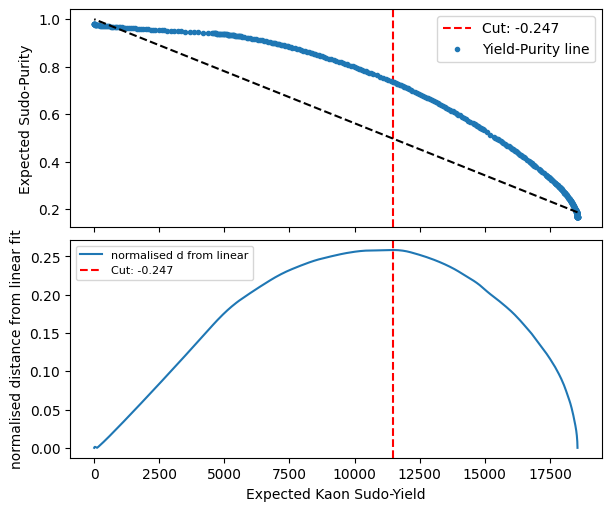

35897
35897


In [4]:
# Unpacking Tree Data
# Note that the simulation tree is called 'PhaseSpaceTree' and does not have the ProbPi/K variables filled.
print('Input data variables:')
print(events_up['DecayTree'].keys())

# These are the arrays to hold the data
pT = []
pX = []
pY = []
pZ = []
prob_k=[]
prob_pi=[]
m_B_all=[]
m_B_all_uncertainties=[]
charge=[]


m_R_neutral_1=[]
m_R_neutral_1_uncertainties=[]
m_R_neutral_2=[]
m_R_neutral_2_uncertainties=[]
m_high_all=[]
m_low_all=[]
probabilities = []


    
# A counter for bookkeeping
event_counter = 0

# If set to a value greater than 0, limits the number of events analysed
# Set to -1 to run over all events. 
# It is recommended to keep the number of events limited while developing the analysis.
MAX_EVENTS = 50000

# Select which set of input data is to be analysed. Uncomment exactly one line
# trees = [events_sim['PhaseSpaceTree']]                       # Simulation
# trees = [events_down['DecayTree']]                          # Magnet down data
#trees = [events_up['DecayTree']]                             # Magnet up data
trees = [events_down['DecayTree'],events_up['DecayTree']]   # Magnet down+up data

# This loop goes over the trees to be analysed
for tree in trees:
    # This outer loop is a technical loop of uproot over chunks of events
#    for data in tree.iterate(['H*_P[XYZ]','H*_Charge','H*_Prob*','H*_isMuon'], library='np'): #not working ...
    for data in tree.iterate( library='np' ):
        # As Python can handle calculations with arrays, we can calculate derived quantities here
        pT_H1 = np.sqrt(data['H1_PX']**2+data['H1_PY']**2)
        pT_H2 = np.sqrt(data['H2_PX']**2+data['H2_PY']**2)
        pT_H3 = np.sqrt(data['H3_PX']**2+data['H3_PY']**2)
        

        # B_meson invariant mass


        m_k=493.667
        # print(len(data['H2_ProbK']))

        # mask1=(Selection_Alg(original_probabilties=data['H1_ProbK']/(data['H1_ProbK']+data['H1_ProbPi']),plotting=False)[0])
        # mask2=(Selection_Alg(original_probabilties=data['H2_ProbK']/(data['H2_ProbK']+data['H2_ProbPi']),plotting=False)[0])
        # mask3=(Selection_Alg(original_probabilties=data['H3_ProbK']/(data['H3_ProbK']+data['H3_ProbPi']),plotting=False)[0])

        mask1=(Selection_Alg(original_probabilties=data['H1_ProbK'],plotting=False)[0])
        mask2=(Selection_Alg(original_probabilties=data['H2_ProbK'],plotting=False)[0])
        mask3=(Selection_Alg(original_probabilties=data['H3_ProbK'],plotting=False)[0])


        # mask1=np.full(len(data['H1_ProbK']),True)
        # mask2=np.full(len(data['H2_ProbK']),True)
        # mask3=np.full(len(data['H2_ProbK']),True)

        # mask1=data['H1_ProbK']>0.9
        # mask2=data['H2_ProbK']>0.9
        # mask3=data['H2_ProbK']>0.9
        total_mask=mask1 & mask2 & mask3

        m_B=B_meson_invariant_mass(data,m_k,mask1,mask2,mask3)
        m_B_uncertainty=mass_uncertainties_B(m_k,data,m_B,mask1,mask2,mask3)
        m_B_all.append(m_B)
        m_B_all_uncertainties.append(m_B_uncertainty)
        
        

        # neutral particles invariant mass
        # data_neutral_mask=(data['H1_Charge'][mask1 & mask2 & mask3] + data['H2_Charge'][mask1 & mask2 & mask3] + data['H3_Charge'][mask1 & mask2 & mask3]).abs()==1
        data_neutral_mask=np.abs(data['H1_Charge'] + data['H2_Charge'] + data['H3_Charge'])==1
        event_mask=data_neutral_mask & mask1 & mask2 & mask3
        H1_different_mask=event_mask & (data['H1_Charge']!=data['H2_Charge']) & (data['H1_Charge']!=data['H3_Charge'])
        H2_different_mask=event_mask & (data['H2_Charge']!=data['H1_Charge']) & (data['H2_Charge']!=data['H3_Charge'])
        H3_different_mask=event_mask & (data['H3_Charge']!=data['H2_Charge']) & (data['H3_Charge']!=data['H1_Charge'])

        m12=calculating_neutral_particle_invariant_mass(data,'H1','H2',m_k)
        m13=calculating_neutral_particle_invariant_mass(data,'H1','H3',m_k)
        m23=calculating_neutral_particle_invariant_mass(data,'H2','H3',m_k)
        
        sigma12 = neutral_mass_uncertainty(data, 'H1', 'H2', m_k, event_mask)
        sigma13 = neutral_mass_uncertainty(data, 'H1', 'H3', m_k, event_mask)
        sigma23 = neutral_mass_uncertainty(data, 'H2', 'H3', m_k, event_mask)

        m_R_neutral_1.append((H1_different_mask*m12 + H2_different_mask*m12 + H3_different_mask*m13)[event_mask])
        m_R_neutral_2.append((H1_different_mask*m13 + H2_different_mask*m23 + H3_different_mask*m23)[event_mask])

        m_R_neutral_1_uncertainties.append(
        np.where(H1_different_mask[event_mask], sigma12,
             np.where(H2_different_mask[event_mask], sigma12,
                      np.where(H3_different_mask[event_mask], sigma13, np.nan))))

        m_R_neutral_2_uncertainties.append(
        np.where(H1_different_mask[event_mask], sigma13,
             np.where(H2_different_mask[event_mask], sigma23,
                      np.where(H3_different_mask[event_mask], sigma23, np.nan))))
        

        event_charge=data['H1_Charge']+data['H2_Charge']+data['H3_Charge']
        charge.append(event_charge[mask1 & mask2 & mask3])

        # This loop will go over individual events
        for i in range(0,len(data['H1_PZ'])):
            event_counter += 1
            if 0 < MAX_EVENTS and MAX_EVENTS < event_counter: break
            if 0 == (event_counter % 100000): print('Read', event_counter, 'events')
            # Decide here which events to analyse
            if (data['H1_PZ'][i] < 0) or (data['H2_PZ'][i] < 0) or (data['H3_PZ'][i] < 0): continue
            if (data['H1_isMuon'][i]==1) or (data['H2_isMuon'][i]==1) or (data['H3_isMuon'][i]==1): continue
            # Fill arrays of events to be plotted and analysed further below
            # Adding values for all three hadrons to the same variable here
            pT.append(pT_H1[i])
            pT.append(pT_H2[i])
            pT.append(pT_H3[i])
            pX.append(data['H1_PX'][i])
            pX.append(data['H2_PX'][i])
            pX.append(data['H3_PX'][i])
            pY.append(data['H1_PY'][i])
            pY.append(data['H2_PY'][i])
            pY.append(data['H3_PY'][i])
            pZ.append(data['H1_PZ'][i])
            pZ.append(data['H2_PZ'][i])
            pZ.append(data['H3_PZ'][i])

            prob_k.append(data['H1_ProbK'][i])
            prob_pi.append(data['H1_ProbPi'][i])
            prob_k.append(data['H2_ProbK'][i])
            prob_pi.append(data['H2_ProbPi'][i])
            prob_k.append(data['H3_ProbK'][i])
            prob_pi.append(data['H3_ProbPi'][i])
            probabilities.append(data['H1_ProbK'][i]/(data['H1_ProbK'][i]+data['H1_ProbPi'][i]))
            probabilities.append(data['H2_ProbK'][i]/(data['H2_ProbK'][i]+data['H2_ProbPi'][i]))
            probabilities.append(data['H3_ProbK'][i]/(data['H3_ProbK'][i]+data['H3_ProbPi'][i]))
print('Read {:d} events'.format(event_counter))
prob_k=np.array(prob_k)
prob_pi=np.array(prob_pi)
pT=np.array(pT)
pX=np.array(pX)
pY=np.array(pY)
pZ=np.array(pZ)





cut,knee_cut=Selection_Alg(original_probabilties=prob_k,plotting=True)
pT=pT[cut]
pX=pX[cut]
pY=pY[cut]
pZ=pZ[cut]
prob_k=prob_k[cut]
prob_pi=prob_pi[cut]

m_B_all=np.concatenate(m_B_all)
m_B_all_uncertainties=np.concatenate(m_B_all_uncertainties)

dalitz_plot_m_B=m_B_all

three_body_mask=(m_B_all>=5250) & (m_B_all<=5300)
m_R_neutral_1=np.concatenate(m_R_neutral_1)
m_R_neutral_1_uncertainties=np.concatenate(m_R_neutral_1_uncertainties)

m_R_neutral_2=np.concatenate(m_R_neutral_2)
m_R_neutral_2_uncertainties=np.concatenate(m_R_neutral_2_uncertainties)


m_high_all=np.maximum(m_R_neutral_1,m_R_neutral_2)
m_low_all=np.minimum(m_R_neutral_1,m_R_neutral_2)

m_high_all_uncertainties=np.maximum(m_R_neutral_1_uncertainties,m_R_neutral_2_uncertainties)
m_low_all_uncertainties=np.minimum(m_R_neutral_1_uncertainties,m_R_neutral_2_uncertainties)

charge=np.concatenate(charge)


print(np.size(m_high_all))
print(np.size(m_B_all))

D_0_mask1=D_0_filter(m_high_all,1864.84,m_high_all_uncertainties)

D_0_mask2=D_0_filter(m_low_all,1864.84,m_low_all_uncertainties)


chi_meson_removal_mask_1 = (~((m_high_all > 3404.21) & (m_high_all < 3425.21)))

chi_meson_removal_mask_2 = (~((m_low_all > 3404.21) & (m_low_all < 3425.21)))

# J_removal_mask=(~((m_high_all >3096.9) & (m_high_all < ))

# print(m_B_all_uncertainties)

total_mask1=D_0_mask1 & chi_meson_removal_mask_1

total_mask2=D_0_mask2 & chi_meson_removal_mask_2



total_removal_mask=total_mask1 & total_mask2

m_B_all=m_B_all[total_removal_mask]

dalitz_plot_m_low=m_low_all
dalitz_plot_m_high=m_high_all

m_high_all=m_high_all[total_mask1]
m_low_all=m_low_all[total_mask2]

charge=charge[total_removal_mask]

positive_B_mask=(charge==1)
negative_B_mask=(charge==-1)
dalitz_plot_m_B=dalitz_plot_m_B[total_removal_mask]
dalitz_plot_m_high=dalitz_plot_m_high[total_removal_mask]
dalitz_plot_m_low=dalitz_plot_m_low[total_removal_mask]


/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_56893/359737418.py:3: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.3) # increase horizontal space between plots


Plotting 1D histogram


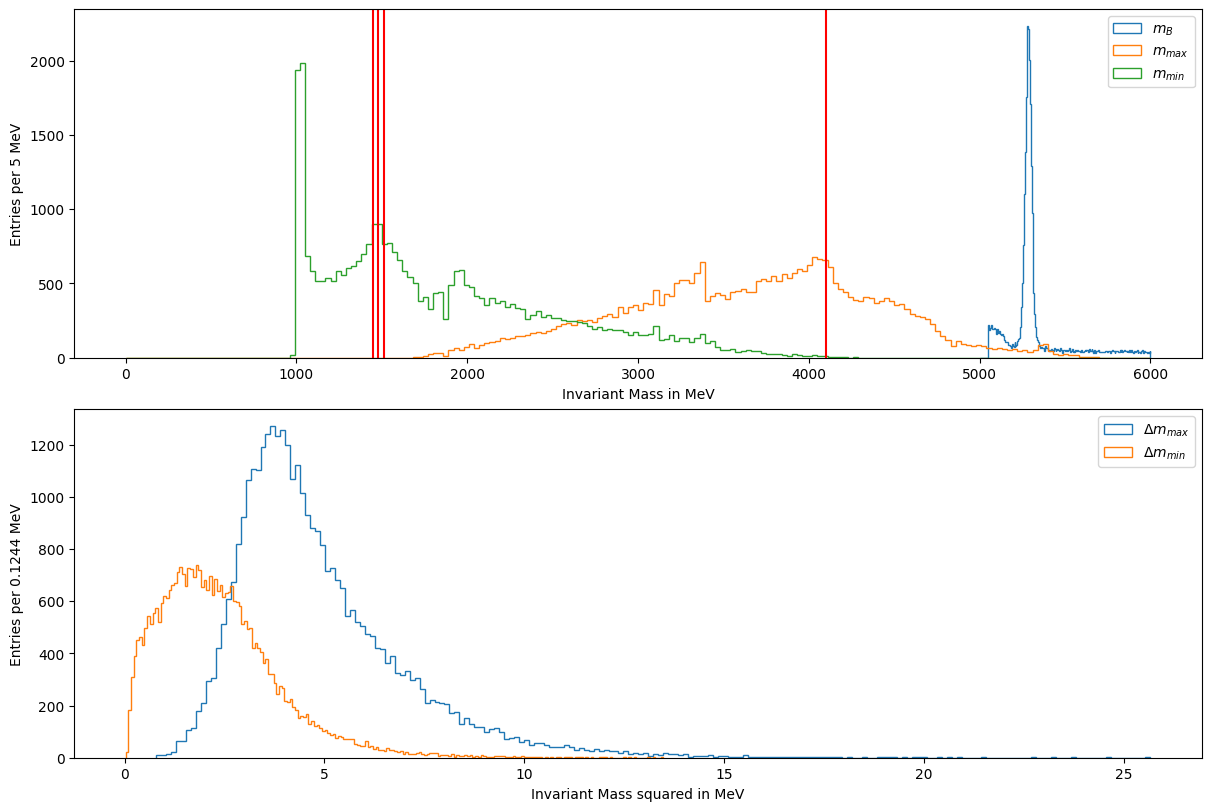

In [5]:
# Invariant Mass Plots
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 8),layout='constrained')
fig.subplots_adjust(wspace=0.3) # increase horizontal space between plots
print('Plotting 1D histogram')
values_m_B,bins_m_B,patches_m_B = ax[0].hist(m_B_all, bins = 200, range = [5000, 6000],histtype='step',label='$m_{B}$')
values_m_R12,bins_m_R12,patches_m_R12 = ax[0].hist(m_high_all, bins = 200, range = [0, 6000],histtype='step',label='$m_{max}$')
values_m_R13,bins_m_R13,patches_m_R13 = ax[0].hist(m_low_all, bins = 200, range = [0, 6000],histtype='step',label='$m_{min}$')

values_delta_m_R12,bins_delta_m_R12,_=ax[1].hist(m_high_all_uncertainties,bins=200,histtype='step',label='$\Delta m_{max}$')
ax[1].hist(m_low_all_uncertainties,bins=200,histtype='step',label='$\Delta m_{min}$')
# # phi strange-antistrange
# ax[0].axvline(1019.461,color='red')
# #f'_2 - mainly strange-anti-strange with some up-anti-up and down-antidown
ax[0].axvline(1512,color='red')
# #eta - even mix of up-anti-up, down-antidown and strange-antistrange
ax[0].axvline(1475,color='red')
# #rho - mainly up-anti-up and down-antidown
ax[0].axvline(1450,color='red')
# # D_0 charm antiup
# ax[0].axvline(1864.84,color='red')

# # 2-3 GeV region is mainly comprised of excited light meson states.
# # J/psi charm-anticharm
# ax[0].axvline(3096.9,color='red')
# #chi_c0 charm-anticharm
# ax[0].axvline(3414.71,color='red')
# # Charmonium (excited) states) and tetra quark candidates in the region of 4GeV - 4.5 GeV
ax[0].axvline(4100,color='red')
# #slight peak before could be from particle misidentification from choosing the wrong kaon candidate.
ax[0].set_xlabel('Invariant Mass in MeV')
bin_width=np.diff(bins_m_B)[0]
ax[0].set_ylabel(f'Entries per {int(bin_width)} MeV')
ax[0].legend()
ax[1].set_xlabel('Invariant Mass squared in MeV')
bin_width=np.diff(bins_delta_m_R12)[0]
ax[1].set_ylabel('Entries per {:.4} MeV'.format(bin_width))
ax[1].legend()




Plotting 1D histogram
Plotting 2D histogram


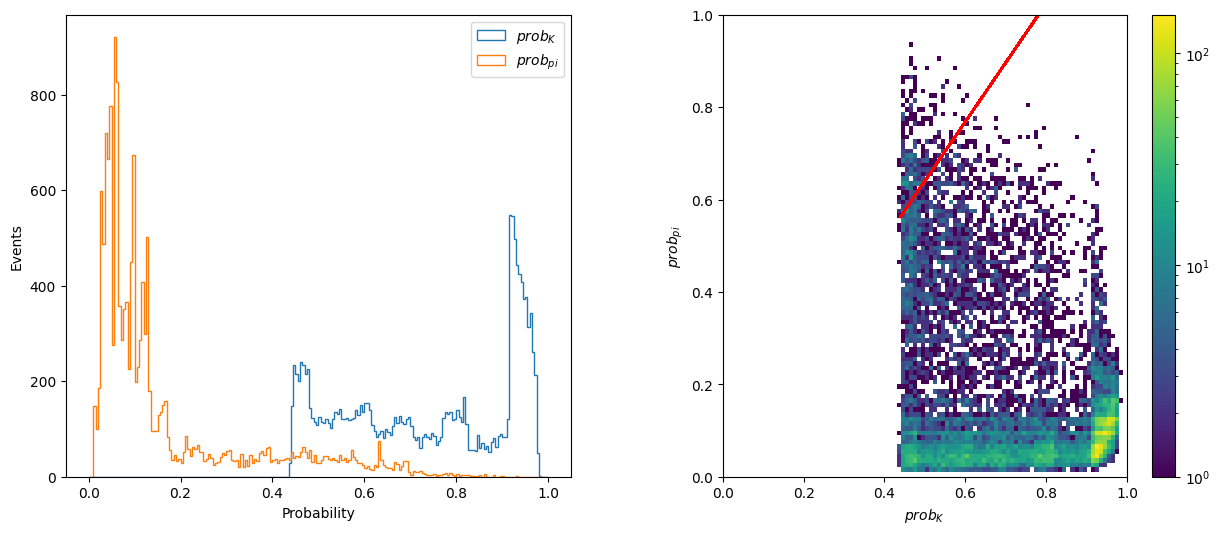

In [6]:
def probabilities_plots():
    # Plot some histograms -- NOTE: this can take several minutes

    # This line produces two plots side-by-side. 
    # It's still useful just for one plot as you can set the size and get the fig,ax objects
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))
    fig.subplots_adjust(wspace=0.3) # increase horizontal space between plots

    # This plots two 1D-histograms.
    # The color is changed automatically, the styles are set by hand
    # keep hold of the pT histogram data for fitting later
    print('Plotting 1D histogram')
    values_prob_k,bins_prob_k,patches_prob_k = ax[0].hist(prob_k, bins = 200, range = [0, 1],histtype='step',label='$prob_{K}$')
    values_prob_pi,bins_prob_pi,patches_prob_pi = ax[0].hist(prob_pi, bins = 200, range = [0, 1],histtype='step',label='$prob_{pi}$')

    #ax[0].hist(pZ, bins = 200, range = [0, 100000],histtype='stepfilled',alpha=0.3,label='$p_{z}$')
    ax[0].set_xlabel('Probability')
    ax[0].set_ylabel('Events')
    ax[0].legend()

    # This plots a 2D-histogram with values converted to GeV and with a logarithmic colour scale
    print('Plotting 2D histogram')
    h2d = ax[1].hist2d(prob_k,prob_pi, bins = [100,100], range = [[0,1],[0,1]],norm=colors.LogNorm())
    ax[1].plot(prob_k,(np.exp(-knee_cut))*prob_k,color='red')
    ax[1].set_xlabel('$prob_{K}$')
    ax[1].set_ylabel('$prob_{pi}$')
    fig.colorbar(h2d[3],ax=ax[1]) # let's add the colour scale
    # plt.savefig('prob_pi_prob_k.png')
probabilities_plots()

### 2 Gaussian Fits + exponential

In [15]:
def root_fitting(m_B_all, mask, canvas, title="B-mass fit"):
    # Make canvas current
    canvas.cd()
    canvas.Clear()

    # RooRealVar
    mB = ROOT.RooRealVar("mB", "B mass [MeV]", 5050, 6300)



    # Signal Gaussian 1
    mean1 = ROOT.RooRealVar("mean1", "signal mean", 5279.31, 5260, 5290) #5290)
    sigma1 = ROOT.RooRealVar("sigma1", "signal sigma", 17, 1, 50)
    N_s1 = ROOT.RooRealVar("N_s1", "signal yield", 10000, 0, 50000)
    gauss1 = ROOT.RooGaussian("gauss1", "signal gaussian", mB, mean1, sigma1)

    # Background exponential
    N_bkg = ROOT.RooRealVar("N_bkg", "bkg yield", 200, 0, 5000)
    k = ROOT.RooRealVar("k", "exp slope", 0.006, -0.1, 0.1)
    exp_bkg = ROOT.RooExponential("exp_bkg", "bkg exp", mB, k)

    # Cut Gaussian
    mean2 = ROOT.RooRealVar("mean2", "cut gaussian mean", 5075, 5050, 5100)
    sigma2 = ROOT.RooRealVar("sigma2", "cut gaussian sigma", 50, 1, 100)
    N2 = ROOT.RooRealVar("N2", "cut gaussian yield", 1000, 0, 5000)
    gauss2 = ROOT.RooGaussian("gauss2", "cut gaussian", mB, mean2, sigma2)

    # Extended PDFs
    ext_gauss1 = ROOT.RooExtendPdf("ext_gauss1", "ext_gauss1", gauss1, N_s1)
    ext_gauss2 = ROOT.RooExtendPdf("ext_gauss2", "ext_gauss2", gauss2, N2)
    ext_expo = ROOT.RooExtendPdf("ext_expo", "ext_expo", exp_bkg, N_bkg)

    # Combined model
    model = ROOT.RooAddPdf("model", "Signal + Cut + Bkg", ROOT.RooArgList(ext_gauss1, ext_gauss2, ext_expo))

    # Create RooDataSet
    data = ROOT.RooDataSet("data", "unbinned data", ROOT.RooArgSet(mB))

    for val in m_B_all[mask]:
        mB.setVal(val)
        data.add(ROOT.RooArgSet(mB))
    result = model.fitTo(data, ROOT.RooFit.Extended(True), ROOT.RooFit.Save())

    # Print fit results
    print(f"Fit results ({title}):")
    for var in [mean1, sigma1, N_s1, mean2, sigma2, N2, k, N_bkg]:
        print(f"{var.GetName():6s}: {var.getVal():.2f} ± {var.getError():.2f}")

    # Plot
    frame = mB.frame(ROOT.RooFit.Title(title))
    data.plotOn(frame,ROOT.RooFit.Name("data_hist"),ROOT.RooFit.Binning(250))
    model.plotOn(frame, ROOT.RooFit.LineColor(ROOT.kRed), ROOT.RooFit.Name("Total"))
    model.plotOn(frame, ROOT.RooFit.Components("ext_gauss1"), ROOT.RooFit.LineColor(ROOT.kGreen), ROOT.RooFit.Name("Signal"))
    model.plotOn(frame, ROOT.RooFit.Components("ext_gauss2"), ROOT.RooFit.LineColor(ROOT.kPink), ROOT.RooFit.Name("CutGaussian"))
    model.plotOn(frame, ROOT.RooFit.Components("ext_expo"), ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.Name("Background"))

    frame.BuildLegend()
    frame.Draw()
    canvas.Update()
    
    n_params = result.floatParsFinal().getSize()
    chi2_red = frame.chiSquare("Total","data_hist",n_params)

    print("Reduced chi2:", chi2_red)
    print("Chi2:", chi2_red*182)

        # Open a new ROOT file
    f = ROOT.TFile(f"fit_results{title}.root", "RECREATE")

    # Save dataset
    data.Write("data")

    # Save model
    model.Write("model")

    # Save yield variables
    result.floatParsFinal().find("N_s1").Write("N_s1")
    result.floatParsFinal().find("N2").Write("N2")
    result.floatParsFinal().find("N_bkg").Write("N_bkg")

    f.Close()


    # ----------------------------
    # Return useful objects
    # ----------------------------
    return {
        "result": result,
        "model": model,
        "frame": frame,
        "chi2_red": chi2_red,
        "N_s1": N_s1,
        "N2": N2,
        "N_bkg": N_bkg,
        "data": data
    }

# --------------------------
# Use the function
# --------------------------
c1 = ROOT.TCanvas("c1", "Positive B", 800, 600)
c2 = ROOT.TCanvas("c2", "Negative B", 800, 600)

result_pos_unbinned = root_fitting(m_B_all, positive_B_mask, c1, "Bpos_mass_fit")
result_neg_unbinned = root_fitting(m_B_all, negative_B_mask, c2, "Bneg_mass_fit")



def chi_squared_poisson(fit,bin_centres,sigma):
    return np.sum((bin_centres-fit)/sigma**2)

print(result_neg_unbinned)


Fit results (Bpos_mass_fit):
mean1 : 5284.30 ± 0.20
sigma1: 18.77 ± 0.17
N_s1  : 10323.96 ± 105.63
mean2 : 5050.00 ± 3.05
sigma2: 100.00 ± 3.02
N2    : 1749.16 ± 57.48
k     : -0.00 ± 0.00
N_bkg : 5000.00 ± 4.13
Reduced chi2: 1.531060170418021
Chi2: 278.6529510160798
Fit results (Bneg_mass_fit):
mean1 : 5284.21 ± 0.24
sigma1: 18.64 ± 0.24
N_s1  : 9276.67 ± 112.82
mean2 : 5050.02 ± 37.50
sigma2: 78.10 ± 74.90
N2    : 1531.40 ± 112.58
k     : -0.00 ± 0.00
N_bkg : 5000.00 ± 5.35
Reduced chi2: 1.132320534726109
Chi2: 206.08233732015182
{'result': <cppyy.gbl.RooFitResult object at 0x15107de20>, 'model': <cppyy.gbl.RooAddPdf object at 0x30f267a00>, 'frame': <cppyy.gbl.RooPlot object at 0x34f3e7050>, 'chi2_red': 1.132320534726109, 'N_s1': <cppyy.gbl.RooRealVar object at 0x37ab3ab40>, 'N2': <cppyy.gbl.RooRealVar object at 0x37ab4ce80>, 'N_bkg': <cppyy.gbl.RooRealVar object at 0x37ab3aed0>, 'data': <cppyy.gbl.RooDataSet object at 0x117e19a30>}
[#1] INFO:Fitting -- RooAbsPdf::fitTo(model) fixing

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c2
Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Evaluated function and gradient in 30.9238 ms
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =      -32355.00555 Edm =        18312.7582 NCalls =     33
Info in <Minuit2>: MnSeedGenerator Initial state  
  Minimum value : -32355.00555
  Edm           : 18312.7582
  Internal parameters:	[    -0.6435011088     -1.168080485    -0.6435011088    0.06003605845     0.2914416015                0     -0.354305169   -0.01010118188]	
  Internal gradient  :	[     -2734.535951     -18855.45247       -2525.9377       144324.527     -2731.139819     -438.1002528     -11948.37003     -2085.809272]	
  Internal covariance matrix:
[[    0.000275436              0              0              0              0              0              0      

[ True False  True ... False False False]
Any NaN in PDF: False
Any zero in PDF: False
Min PDF value: 0.00017622999814749456
Any NaN in PDF: False
Any zero in PDF: False
Min PDF value: 0.0001732944808674077


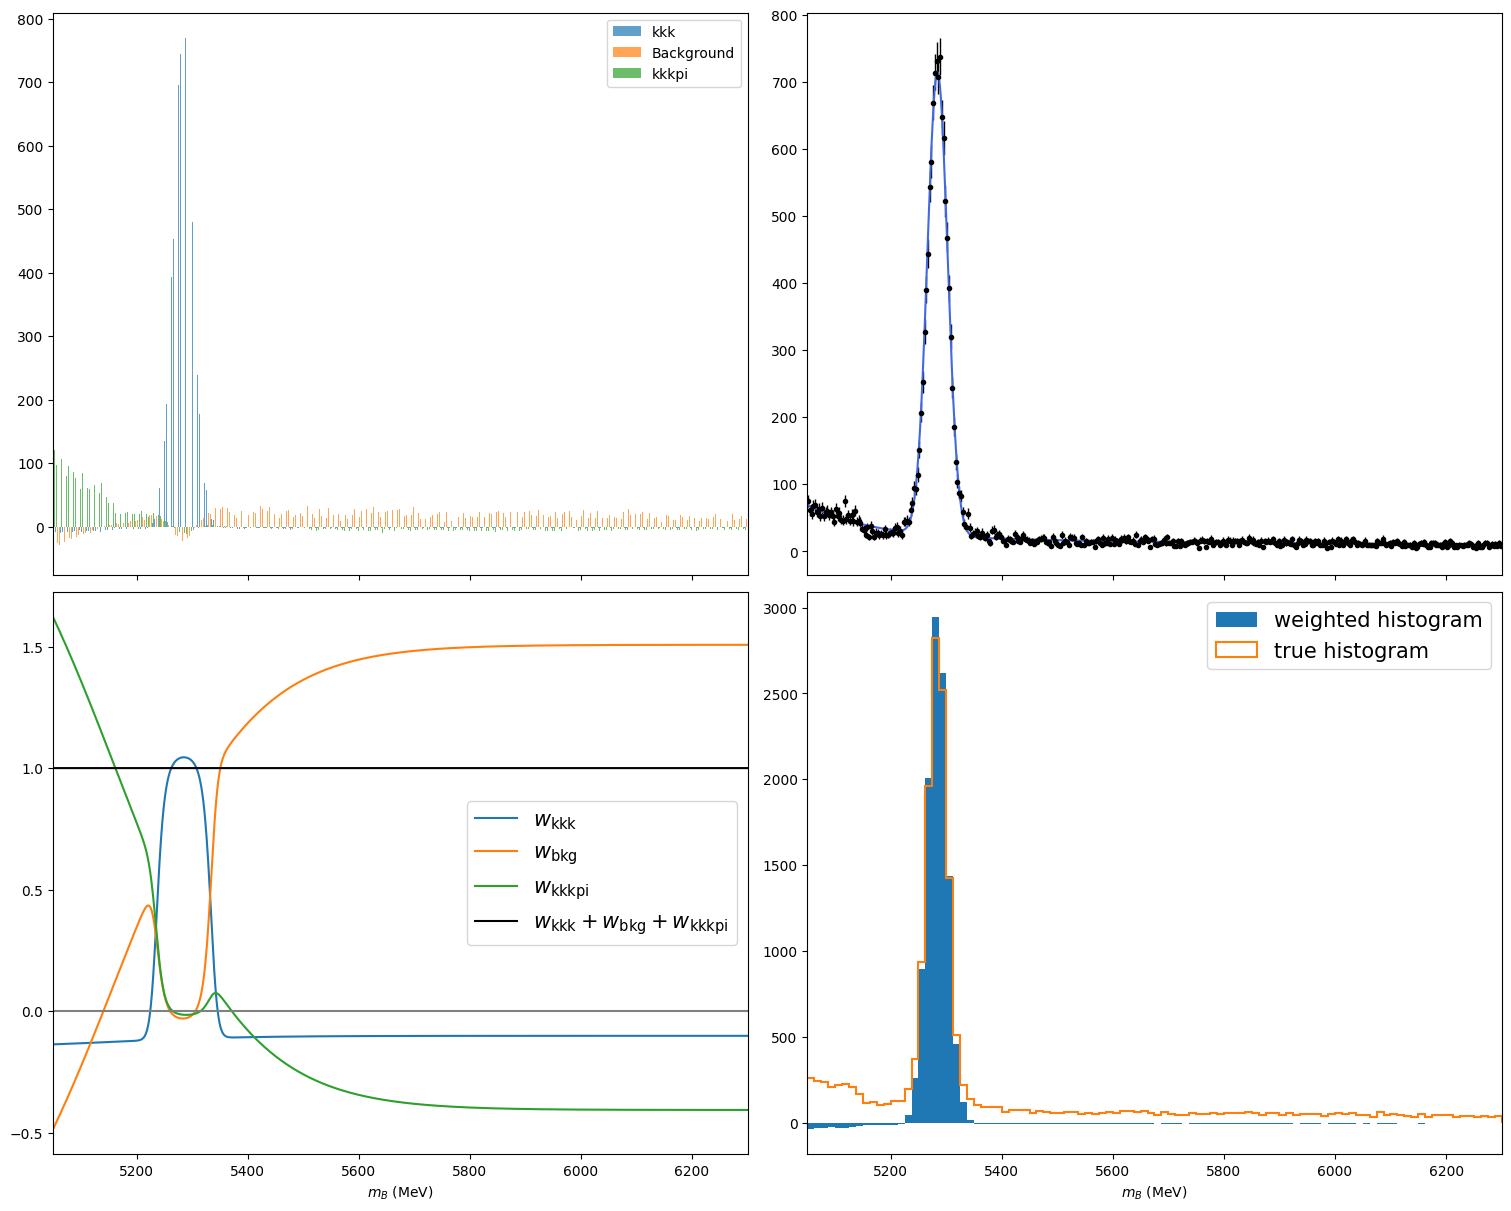

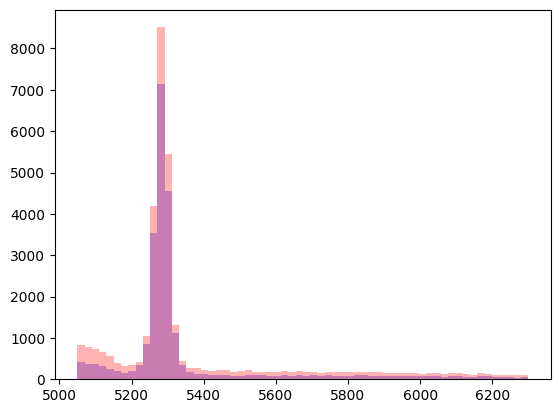

In [19]:
# sPlot 2 x Gaussian + exponential
def sPlot2G1e(result_neg_unbinned=result_neg_unbinned,result_pos_unbinned=result_pos_unbinned):
    def gauss(x, x0, sigma,N_s1):
        return (1/(sigma+np.sqrt(2*np.pi)))*np.exp(-(x - x0)**2 / (2 * sigma**2))
    def exponential(x,lambda_,N_bkg):
        return -lambda_*np.exp(lambda_*x)


    def naive_weights(result_pos_unbinned,result_neg_unbinned,positive_B_mask,negative_B_mask):
        def probs(x,mean_signal,std_signal,lambda_,N_s1,N2,N_bkg,mean2,signal2):
            signal=gauss(x,mean_signal,std_signal,N_s1)
            e=exponential(x,lambda_,N_bkg)
            kkkp=gauss(x,mean2,signal2,N2)
            prob_signal=signal/(signal+e)
            prob_e=e/(signal+e)
            prob_kkkp=kkkp/(signal+e+kkkp)
            return prob_signal,prob_e,prob_kkkp
        def retrieving_vals(unbinned_array):
                mean_signal=unbinned_array['result'].floatParsFinal().find("mean1").getVal()
                std_signal=unbinned_array['result'].floatParsFinal().find("sigma1").getVal()
                lambda_=unbinned_array['result'].floatParsFinal().find("k").getVal()
                N_s1=unbinned_array['N_s1'].getVal()
                N2=unbinned_array['N2'].getVal()
                mean_signal_2=unbinned_array['result'].floatParsFinal().find("mean2").getVal()
                std_signal_2=unbinned_array['result'].floatParsFinal().find("sigma2").getVal()
                N_bkg=unbinned_array['N_bkg'].getVal()
                return mean_signal,std_signal,lambda_,N_s1,N2,N_bkg,mean_signal_2,std_signal_2
        neg_fits_vals=retrieving_vals(result_neg_unbinned)
        pos_fits_vals=retrieving_vals(result_pos_unbinned)
        naive_weights_signal_pos,_,_=probs(dalitz_plot_m_B[positive_B_mask],*pos_fits_vals)
        naive_weights_signal_neg,_,_=probs(dalitz_plot_m_B[negative_B_mask],*neg_fits_vals)
        return naive_weights_signal_pos,naive_weights_signal_neg
            # naive_weights_signal_pos,_,_=probs(dalitz_plot_m_B[positive_B_mask],mean_signal,std_signal,lambda_,N_s1,N2,N_bkg,mean_signal_2,std_signal_2)
            # naive_weights_signal_neg,_,_=probs(dalitz_plot_m_B[negative_B_mask],mean_signal,std_signal,lambda_,N_s1,N2,N_bkg,mean_signal_2,std_signal_2)
    naive_weights_signal_pos,naive_weights_signal_neg = naive_weights(result_pos_unbinned=result_pos_unbinned,result_neg_unbinned=result_neg_unbinned,positive_B_mask=positive_B_mask,negative_B_mask=negative_B_mask)
    fig,ax=plt.subplots(2,2,figsize=(15,12),layout='constrained',sharex=True)
    def filtering_with_random_numbers_naive(naive_weights_signal_pos,naive_weights_signal_neg):

        random_number=np.random.randn(len(dalitz_plot_m_B[positive_B_mask]))

        positive_mask_naive_signal= (random_number<naive_weights_signal_pos)

        random_number=np.random.randn(len(dalitz_plot_m_B[negative_B_mask]))

        negative_mask_naive_signal= (random_number<naive_weights_signal_neg)
        print(negative_mask_naive_signal)
        total_mask_naive_signal=np.zeros(len(dalitz_plot_m_B),dtype=bool)
        total_mask_naive_signal[positive_B_mask]=positive_mask_naive_signal
        total_mask_naive_signal[negative_B_mask]=negative_mask_naive_signal
        
        dalitz_plot_m_high_filtered=dalitz_plot_m_high[total_mask_naive_signal]
        dalitz_plot_m_low_filtered=dalitz_plot_m_low[total_mask_naive_signal]
        return dalitz_plot_m_high_filtered,dalitz_plot_m_low_filtered,total_mask_naive_signal
    dalitz_plot_m_high_filtered,dalitz_plot_m_low_filtered,mask=filtering_with_random_numbers_naive(naive_weights_signal_pos,naive_weights_signal_neg)
    total_naive_weighting_signal=np.zeros(len(dalitz_plot_m_B))
    total_naive_weighting_signal[positive_B_mask]=naive_weights_signal_pos
    total_naive_weighting_signal[negative_B_mask]=naive_weights_signal_neg

    def raw_sPlot(masses, result):
    # import numpy as np
    # import zfit
    # from hepstats.splot import compute_sweights

        obs = zfit.Space('mass', (5050, 6300))
        data_z = zfit.Data.from_numpy(obs=obs, array=masses)
        uid = np.random.randint(0, 1e9)

        # Helper to extract parameter values from zfit FitResult
        def get_param(result, name):
            for p in result.params:
                if p.name == name:
                    return result.params[p]['value']
            raise KeyError(name)

        # --- Clip shape parameters to allowed ranges to avoid ValueError ---
        mean1_val = np.clip(get_param(result, "mean1"), 5260., 5290.)
        sigma1_val = np.clip(get_param(result, "sigma1"), 1., 50.)
        mean2_val = np.clip(get_param(result, "mean2"), 5050., 5100.)
        sigma2_val = np.clip(get_param(result, "sigma2"), 1., 100.)
        lam_val = np.clip(get_param(result, "lambda"), -0.1, 0.1)

        # --- Build zfit Parameters ---
        # FIX shape parameters for stability
        mean1  = zfit.Parameter(f"mean1_{uid}", mean1_val, floating=False)
        sigma1 = zfit.Parameter(f"sigma1_{uid}", sigma1_val, floating=False)
        mean2  = zfit.Parameter(f"mean2_{uid}", mean2_val, floating=False)
        sigma2 = zfit.Parameter(f"sigma2_{uid}", sigma2_val, floating=False)
        lam    = zfit.Parameter(f"lambda_{uid}", lam_val, -0.1, 0.1)  # can float if desired

        # --- Yields (floating) ---
        sig_yield = zfit.Parameter(f"N_s1_{uid}",  get_param(result,'N_s1'), 0., 50000.)
        cut_yield = zfit.Parameter(f"N2_{uid}",    get_param(result,"N2"), 0., 5000.)
        bkg_yield = zfit.Parameter(f"N_bkg_{uid}", get_param(result,"N_bkg"), 0., 10000.)

        # --- Build PDFs ---
        gauss1 = zfit.pdf.Gauss(obs=obs, mu=mean1, sigma=sigma1)
        gauss2 = zfit.pdf.Gauss(obs=obs, mu=mean2, sigma=sigma2)
        expo   = zfit.pdf.Exponential(obs=obs, lam=lam)

        # --- Extended PDFs ---
        ext_gauss1 = gauss1.create_extended(sig_yield)
        ext_gauss2 = gauss2.create_extended(cut_yield)
        ext_expo   = expo.create_extended(bkg_yield)

        # --- Combined model ---
        model = zfit.pdf.SumPDF([ext_gauss1, ext_gauss2, ext_expo])

        # --- Fit ---
        nll = zfit.loss.ExtendedUnbinnedNLL(model, data_z)
        result_fit = zfit.minimize.Minuit(use_minuit_grad=True).minimize(nll)
        if not result_fit.converged:
            print("Fit did not converge")
            return None

        # print("Fit converged:", result_fit.converged, "Valid:", result_fit.valid, "Hesse valid:", result_fit.hesse_valid)

        # --- Compute sWeights ---
        weights = compute_sweights(model, data_z)

        # Return sWeights for the signal yield
        return weights[sig_yield]



    def parametric_boostrapping(nominal_fit,result,data,bin_edges,n_resamples=500):
        N=len(data)
        boot_hists=[]
        for i in range(n_resamples):
            sampled_mass=nominal_fit.sample(N).numpy().flatten()

            weights_boot=raw_sPlot(sampled_mass,result)
            if weights_boot is None:
                continue

            hist,_=np.histogram(sampled_mass,bins=bin_edges,weights=weights_boot)
            boot_hists.append(hist)
        boot_hists=np.array(boot_hists)

        return {
            'mean': boot_hists.mean(axis=0),
            'std': boot_hists.std(axis=0),
            'hists': boot_hists
        }

    def manual_s_plot(result,data,ax,plotting=True):
        data_np = data
        
        obs = zfit.Space('mass', (5050, 6300))
        data_z_fit=zfit.Data.from_numpy(obs=obs,array=data_np)
        
        # Extract mean/sigma/lambda values from RooFit result
        res = result["result"].floatParsFinal()
        mean1_val  = res.find("mean1").getVal()
        sigma1_val = res.find("sigma1").getVal()
        mean2_val  = res.find("mean2").getVal()
        sigma2_val = res.find("sigma2").getVal()
        k_val      = res.find("k").getVal()

        # Extract yields
        N_s1_val  = res.find("N_s1").getVal()
        N2_val    = res.find("N2").getVal()
        N_bkg_val = res.find("N_bkg").getVal()

        # Build zfit parameters
        mean1  = zfit.Parameter("mean1", mean1_val)
        sigma1 = zfit.Parameter("sigma1", sigma1_val)
        mean2  = zfit.Parameter("mean2", mean2_val)
        sigma2 = zfit.Parameter("sigma2", sigma2_val)
        lam    = zfit.Parameter("lambda", k_val)

        sig_yield = zfit.Parameter("N_s1", N_s1_val)
        cut_yield = zfit.Parameter("N2", N2_val)
        bkg_yield = zfit.Parameter("N_bkg", N_bkg_val)

        # Build PDFs
        gauss1 = zfit.pdf.Gauss(obs=obs, mu=mean1, sigma=sigma1)
        gauss2 = zfit.pdf.Gauss(obs=obs, mu=mean2, sigma=sigma2)
        expo   = zfit.pdf.Exponential(obs=obs, lam=lam)

        # Extended PDFs
        ext_gauss1 = gauss1.create_extended(sig_yield)
        ext_gauss2 = gauss2.create_extended(cut_yield)
        ext_expo   = expo.create_extended(bkg_yield)

        # Combined model
        model = zfit.pdf.SumPDF([ext_gauss1, ext_gauss2, ext_expo])

        pdf_values = model.pdf(data_z_fit)
        print(f"Any NaN in PDF: {np.any(np.isnan(pdf_values.numpy()))}")
        print(f"Any zero in PDF: {np.any(pdf_values.numpy() == 0)}")
        print(f"Min PDF value: {pdf_values.numpy().min()}")


        # # Signal distributions.
        # nsig_sw = 20000
        # np_sig_m_sw = gauss1.sample(nsig_sw).numpy().reshape(-1,)
        # np_sig_t_sw = np.random.exponential(size=nsig_sw, scale=1)

        # # Background distributions.
        # nbkg_sw = 20000
        # np_bkg_m_sw = expo.sample(nbkg_sw).numpy().reshape(-1,)
        # np_bkg_t_sw = np.random.normal(size=nbkg_sw, loc=2.0, scale=2.5)

        # ax[0][0].hist([np_bkg_m_sw, np_sig_m_sw], bins=100, stacked=True, label=("background", "signal"), alpha=.7)
        
        counts, bin_edges = np.histogram(data_np, bins=400)
        
        data_sw = zfit.Data.from_numpy(obs=obs, array=data_np)
        nll = zfit.loss.ExtendedUnbinnedNLL(model, data_sw)  # data_zfit = your actual data

        result=zfit.minimize.Minuit(use_minuit_grad=True).minimize(nll)

        weights = compute_sweights(model, data_sw)




        sorter = data_np.argsort()

        

        if plotting:
            mplhep.histplot(counts, bins=bin_edges, histtype="errorbar", yerr=True,
                        label="Data", ax=ax[0][1], color="black")
            bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
            binwidth = np.diff(bin_edges)[0]

            x = np.linspace(5050, 6300, num=1000)  # or np.linspace

            # Line plots of the total pdf and the sub-pdfs.
            y = model.ext_pdf(x) * binwidth
            ax[0][1].plot(x, y, label="total", color="royalblue")


            # Individual components scaled to yield per bin
            signal_pdf_vals = ext_gauss1.ext_pdf(x) * binwidth
            cut_pdf_vals    = ext_gauss2.ext_pdf(x) * binwidth
            bkg_pdf_vals    = ext_expo.ext_pdf(x) * binwidth


            ax[0][0].hist(
            [data_np[sorter], data_np[sorter],data_np[sorter]],  # same data, weights will separate components
            bins=bin_edges,
            weights=[weights[sig_yield][sorter], weights[bkg_yield][sorter], weights[cut_yield][sorter]],
            stacked=False,
            label=["kkk", "Background", "kkkpi"],
            alpha=0.7)
            ax[0][0].legend()

        

            ax[1][0].plot(data_np[sorter], weights[sig_yield][sorter], label="$w_\\mathrm{kkk}$")
            ax[1][0].plot(data_np[sorter], weights[bkg_yield][sorter], label="$w_\\mathrm{bkg}$")
            ax[1][0].plot(data_np[sorter], weights[cut_yield][sorter], label="$w_\\mathrm{kkkpi}$")
            ax[1][0].plot(data_np[sorter], weights[sig_yield][sorter] + weights[bkg_yield][sorter] + weights[cut_yield][sorter],
                        "-k", label="$w_\\mathrm{kkk} + w_\\mathrm{bkg} + w_\\mathrm{kkkpi}$")
            ax[1][0].axhline(0, color="0.5")
            ax[1][0].legend(fontsize=15)
            ax[1][0].set_xlim(5050, 6300)

            ax[1][1].hist(data_np,bins=100,weights=weights[sig_yield],label='weighted histogram')
            ax[1][1].hist(data_np,bins=100,histtype="step",lw=1.5,label='true histogram')
            ax[1][1].legend(fontsize=15)
            ax[1][0].set_xlabel("$m_B$ (MeV)")
            ax[1][1].set_xlabel("$m_B$ (MeV)")
        
        return weights[sig_yield], model ,result
    bin_edges = np.linspace(5050, 6300, 201)  # 50 bins, completely your choice
    weights_pos,model_pos,result_pos=manual_s_plot(result_pos_unbinned,dalitz_plot_m_B[positive_B_mask],ax,plotting=True)
    pos_boostrap_data=parametric_boostrapping(model_pos,result_pos,dalitz_plot_m_B[positive_B_mask],bin_edges,n_resamples=10)
    weights_neg,model_neg,result_neg=manual_s_plot(result_neg_unbinned,dalitz_plot_m_B[negative_B_mask],ax,plotting=False)
    neg_boostrap_data=parametric_boostrapping(model_neg,result_neg,dalitz_plot_m_B[negative_B_mask],bin_edges,n_resamples=10)

    fig,ax=plt.subplots(1)
    ax.hist(dalitz_plot_m_B[mask],bins=int((max(dalitz_plot_m_B[mask])-min(dalitz_plot_m_B[mask]))/20),color='blue',alpha=0.3)
    ax.hist(dalitz_plot_m_B,bins=int((max(dalitz_plot_m_B)-min(dalitz_plot_m_B))/20),color='red',alpha=0.3)
    return weights_pos, weights_neg, pos_boostrap_data, neg_boostrap_data
weights_pos, weights_neg, pos_boostrap_data, neg_boostrap_data = sPlot2G1e()
    # plt.plot(dalitz_plot_m_B,total_naive_weighting_signal,color='k')
    # plt.plot(dalitz_plot_m_B_side_cuts,values_e)
    # plt.show()




### 2 Cauchy and exponential Refitting

In [21]:
def root_fitting_cauchy(m_B_all,mask,canvas,title="B-mass fit"):

    canvas.cd()
    canvas.Clear()

    # RooRealVar
    mB = ROOT.RooRealVar("mB", "B mass [MeV]", 5050, 6300)



    # Signal cauchy 1
    mean1 = ROOT.RooRealVar("mean1", "signal mean", 5279.31, 5260, 5290) #5290)
    sigma1 = ROOT.RooRealVar("sigma1", "signal sigma", 7, 1, 50)
    N_s1 = ROOT.RooRealVar("N_s1", "signal yield", 10000, 0, 50000)
    # gauss1 = ROOT.Roocauchy("gauss1", "signal cauchy", mB, mean1, sigma1)
    cauchy1 = ROOT.RooBreitWigner("cauchy1","signal cauchy",mB,mean1,sigma1) #using sigma as HWHH

    # Background exponential
    N_bkg = ROOT.RooRealVar("N_bkg", "bkg yield", 200, 0, 5000)
    k = ROOT.RooRealVar("k", "exp slope", 0.006, -0.1, 0.1)
    exp_bkg = ROOT.RooExponential("exp_bkg", "bkg exp", mB,k)

    # Cut cauchy
    mean2 = ROOT.RooRealVar("mean2", "cut cauchy mean", 5075, 5050, 5100)
    sigma2 = ROOT.RooRealVar("sigma2", "cut cauchy sigma", 15, 1, 100)
    N2 = ROOT.RooRealVar("N2", "cut cauchy yield", 1000, 0, 5000)
    cauchy2 = ROOT.RooBreitWigner("cauchy2", "cut cauchy", mB, mean2, sigma2)

    # Extended PDFs
    ext_gauss1 = ROOT.RooExtendPdf("ext_cauchy1", "ext_cauchy1", cauchy1, N_s1)
    ext_gauss2 = ROOT.RooExtendPdf("ext_cauchy2", "ext_cauchy2", cauchy2, N2)
    ext_expo = ROOT.RooExtendPdf("ext_uniform", "ext_uniform", exp_bkg, N_bkg)

    # Combined model
    model = ROOT.RooAddPdf("model", "Signal + Cut + Bkg", ROOT.RooArgList(ext_gauss1, ext_gauss2, ext_expo))

    # Create RooDataSet
    data = ROOT.RooDataSet("data", "unbinned data", ROOT.RooArgSet(mB))

    for val in m_B_all[mask]:
        mB.setVal(val)
        data.add(ROOT.RooArgSet(mB))
    result = model.fitTo(data, ROOT.RooFit.Extended(True), ROOT.RooFit.Save())

    # Print fit results
    print(f"Fit results ({title}):")
    for var in [mean1, sigma1, N_s1, mean2, sigma2, N2, k, N_bkg]:
        print(f"{var.GetName():6s}: {var.getVal():.2f} ± {var.getError():.2f}")

    # Plot
    frame = mB.frame(ROOT.RooFit.Title(title))
    data.plotOn(frame,ROOT.RooFit.Name("data_hist"),ROOT.RooFit.Binning(250))
    model.plotOn(frame, ROOT.RooFit.LineColor(ROOT.kRed), ROOT.RooFit.Name("Total"))
    model.plotOn(frame, ROOT.RooFit.Components("ext_gauss1"), ROOT.RooFit.LineColor(ROOT.kGreen), ROOT.RooFit.Name("Signal"))
    model.plotOn(frame, ROOT.RooFit.Components("ext_gauss2"), ROOT.RooFit.LineColor(ROOT.kPink), ROOT.RooFit.Name("Cutcauchy"))
    model.plotOn(frame, ROOT.RooFit.Components("ext_expo"), ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.Name("Background"))

    frame.BuildLegend()
    frame.Draw()
    canvas.Update()
    
    n_params = result.floatParsFinal().getSize()
    chi2_red = frame.chiSquare("Total","data_hist",n_params)

    print("Reduced chi2:", chi2_red)
    print("Chi2:", chi2_red*182)

        # Open a new ROOT file
    f = ROOT.TFile(f"fit_results{title}.root", "RECREATE")

    # Save dataset
    data.Write("data")

    # Save model
    model.Write("model")

    # Save yield variables
    result.floatParsFinal().find("N_s1").Write("N_s1")
    result.floatParsFinal().find("N2").Write("N2")
    result.floatParsFinal().find("N_bkg").Write("N_bkg")

    f.Close()


    # ----------------------------
    # Return useful objects
    # ----------------------------
    return {
        "result": result,
        "model": model,
        "frame": frame,
        "chi2_red": chi2_red,
        "N_s1": N_s1,
        "N2": N2,
        "N_bkg": N_bkg,
        "data": data
    }

# --------------------------
# Use the function
# --------------------------
c1 = ROOT.TCanvas("c1", "Positive B", 800, 600)
c2 = ROOT.TCanvas("c2", "Negative B", 800, 600)

result_pos_unbinned_cauchy = root_fitting_cauchy(m_B_all, positive_B_mask, c1, "Bpos_mass_fit")
result_neg_unbinned_cauchy = root_fitting_cauchy(m_B_all, negative_B_mask, c2, "Bneg_mass_fit")



def chi_squared_poisson(fit,bin_centres,sigma):
    return np.sum((bin_centres-fit)/sigma**2)


Fit results (Bpos_mass_fit):
mean1 : 5284.21 ± 0.20
sigma1: 28.70 ± 0.41
N_s1  : 11856.53 ± 121.54
mean2 : 5077.30 ± 3.04
sigma2: 90.01 ± 6.01
N2    : 1568.79 ± 68.09
k     : 0.00 ± 0.00
N_bkg : 4253.31 ± 99.10
Reduced chi2: 3.359858893985564
Chi2: 611.4943187053726
Fit results (Bneg_mass_fit):
mean1 : 5284.28 ± 0.21
sigma1: 27.94 ± 0.42
N_s1  : 10519.22 ± 114.68
mean2 : 5079.67 ± 2.26
sigma2: 78.63 ± 5.11
N2    : 1563.98 ± 65.82
k     : -0.00 ± 0.00
N_bkg : 4186.61 ± 98.12
Reduced chi2: 3.640231769612765
Chi2: 662.5221820695233
[#1] INFO:Fitting -- RooAbsPdf::fitTo(model) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- Creation of NLL object took 3.68871 ms
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_model_data) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- [fitFCN] No discrete parameters, perform

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c2
Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Evaluated function and gradient in 29.829 ms
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =      -32927.75914 Edm =       403446028.2 NCalls =     35
Info in <Minuit2>: NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
Info in <Minuit2>: NegativeG2LineSearch Done after 12.5742 ms
Info in <Minuit2>: MnSeedGenerator Negative G2 found - new state: 
  Minimum value : -33875.00803
  Edm           : 11781.46534
  Internal parameters:	[    -0.6435011088     -1.168080485    -0.6435011088     0.0165794544     0.2914416015                0    -0.8558097488       -0.7997354]	
  Internal gradient  :	[      -1405.45159      -11993.8635     -6656.084592      86.53304424     -3683.044122     -38

[ True False  True ...  True  True  True]
Any NaN in PDF: False
Any zero in PDF: False
Min PDF value: 0.0001842157293194102
Any NaN in PDF: False
Any zero in PDF: False
Min PDF value: 0.00017997758596058106


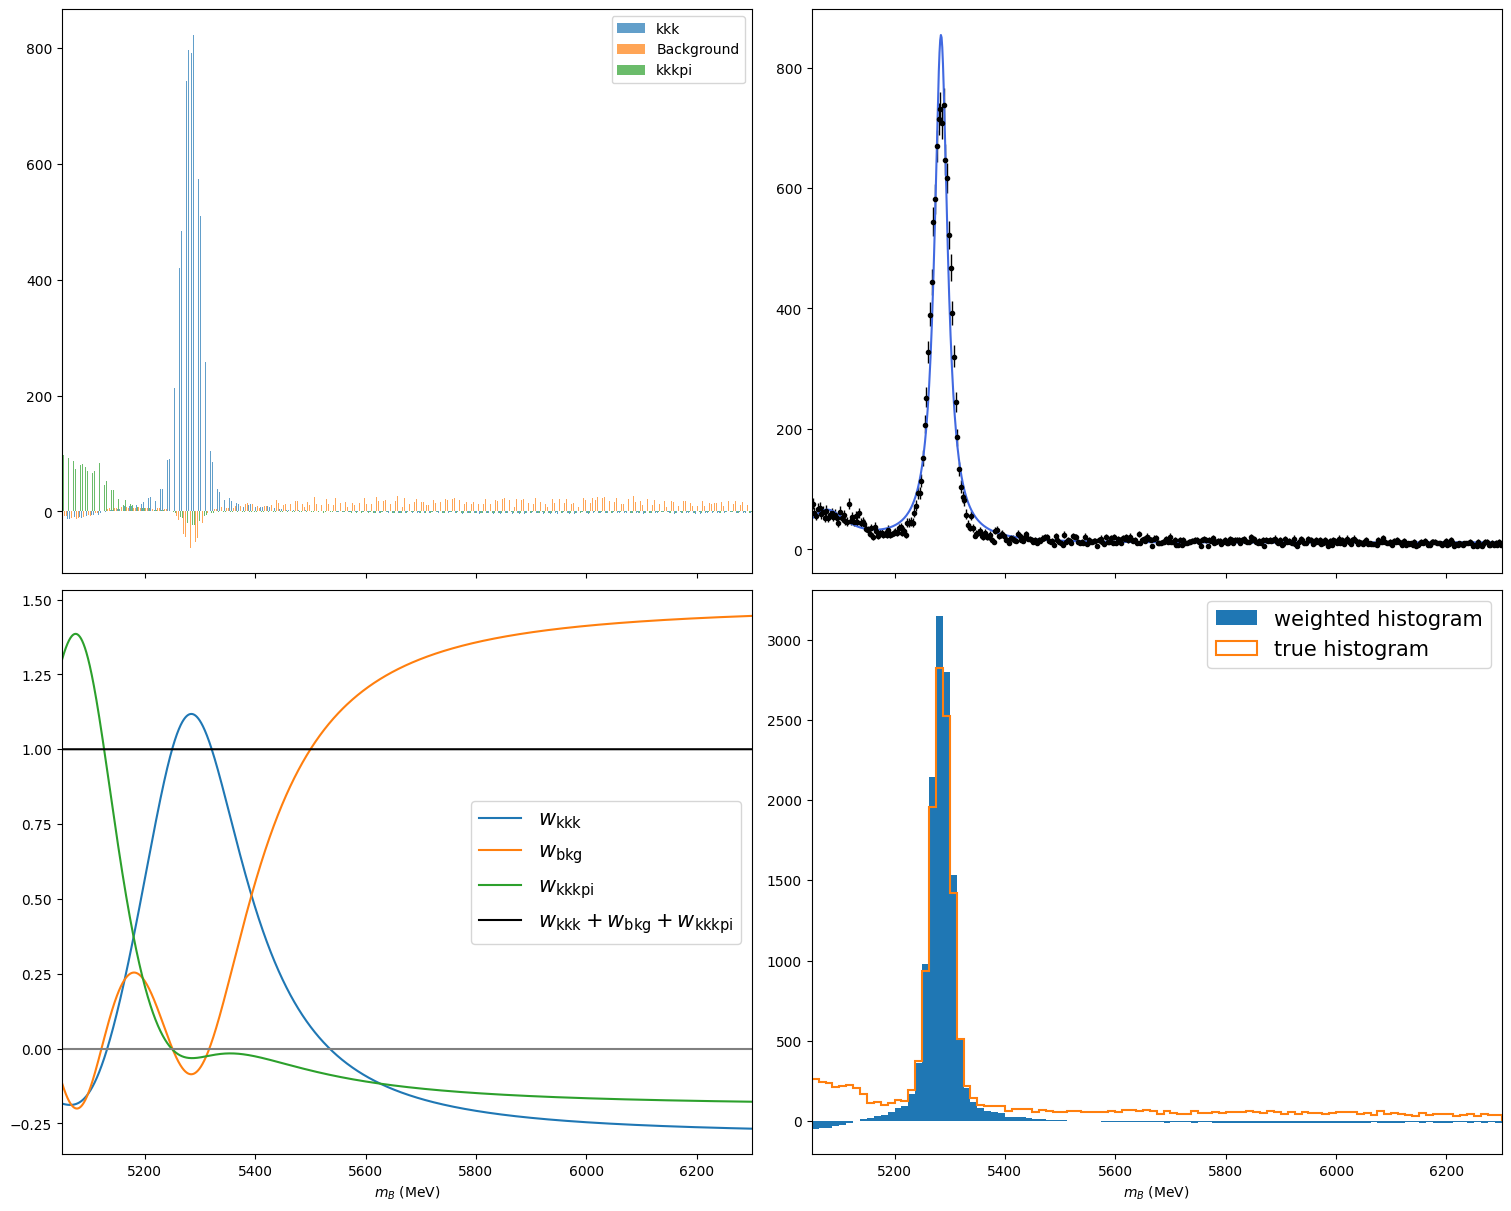

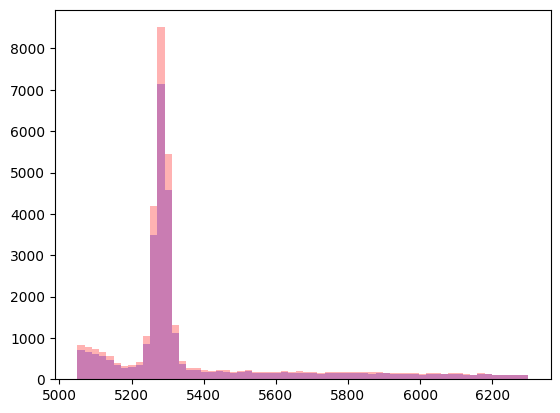

In [22]:
# sPlot fitting 2x Cauchy + exponential
def sPlot2C1e(result_neg_unbinned_cauchy=result_neg_unbinned_cauchy,result_pos_unbinned_cauchy=result_pos_unbinned_cauchy):
    def cauchy(x, x0, gamma,N_s1):
        return N_s1 * (1/np.pi) * (gamma / ((x - x0)**2 + gamma**2))
    def exponential(x,lambda_,N_bkg):
        return -lambda_*np.exp(lambda_*x)

    def naive_weights(result_pos_unbinned,result_neg_unbinned,positive_B_mask,negative_B_mask):
        def probs(x,mean_signal,std_signal,lambda_,N_s1,N2,N_bkg,mean2,signal2):
            signal=cauchy(x,mean_signal,std_signal,N_s1)
            e=exponential(x,lambda_,N_bkg)
            kkkp=cauchy(x,mean2,signal2,N2)
            prob_signal=signal/(signal+e)
            prob_e=e/(signal+e)
            prob_kkkp=kkkp/(signal+e+kkkp)
            return prob_signal,prob_e,prob_kkkp
        def retrieving_vals(unbinned_array):
                mean_signal=unbinned_array['result'].floatParsFinal().find("mean1").getVal()
                std_signal=unbinned_array['result'].floatParsFinal().find("sigma1").getVal()
                lambda_=unbinned_array['result'].floatParsFinal().find("k").getVal()
                N_s1=unbinned_array['N_s1'].getVal()
                N2=unbinned_array['N2'].getVal()
                mean_signal_2=unbinned_array['result'].floatParsFinal().find("mean2").getVal()
                std_signal_2=unbinned_array['result'].floatParsFinal().find("sigma2").getVal()
                N_bkg=unbinned_array['N_bkg'].getVal()
                return mean_signal,std_signal,lambda_,N_s1,N2,N_bkg,mean_signal_2,std_signal_2
        neg_fits_vals=retrieving_vals(result_neg_unbinned)
        pos_fits_vals=retrieving_vals(result_pos_unbinned)
        naive_weights_signal_pos,_,_=probs(dalitz_plot_m_B[positive_B_mask],*pos_fits_vals)
        naive_weights_signal_neg,_,_=probs(dalitz_plot_m_B[negative_B_mask],*neg_fits_vals)
        return naive_weights_signal_pos,naive_weights_signal_neg
            # naive_weights_signal_pos,_,_=probs(dalitz_plot_m_B[positive_B_mask],mean_signal,std_signal,lambda_,N_s1,N2,N_bkg,mean_signal_2,std_signal_2)
            # naive_weights_signal_neg,_,_=probs(dalitz_plot_m_B[negative_B_mask],mean_signal,std_signal,lambda_,N_s1,N2,N_bkg,mean_signal_2,std_signal_2)
    naive_weights_signal_pos_cauchy,naive_weights_signal_neg_cauchy = naive_weights(result_pos_unbinned=result_pos_unbinned_cauchy,result_neg_unbinned=result_neg_unbinned_cauchy,positive_B_mask=positive_B_mask,negative_B_mask=negative_B_mask)
    fig,ax=plt.subplots(2,2,figsize=(15,12),layout='constrained',sharex=True)
    def filtering_with_random_numbers_naive(naive_weights_signal_pos,naive_weights_signal_neg):

        random_number=np.random.randn(len(dalitz_plot_m_B[positive_B_mask]))

        positive_mask_naive_signal= (random_number<naive_weights_signal_pos)

        random_number=np.random.randn(len(dalitz_plot_m_B[negative_B_mask]))

        negative_mask_naive_signal= (random_number<naive_weights_signal_neg)
        print(negative_mask_naive_signal)
        total_mask_naive_signal=np.zeros(len(dalitz_plot_m_B),dtype=bool)
        total_mask_naive_signal[positive_B_mask]=positive_mask_naive_signal
        total_mask_naive_signal[negative_B_mask]=negative_mask_naive_signal
        
        dalitz_plot_m_high_filtered=dalitz_plot_m_high[total_mask_naive_signal]
        dalitz_plot_m_low_filtered=dalitz_plot_m_low[total_mask_naive_signal]
        return dalitz_plot_m_high_filtered,dalitz_plot_m_low_filtered,total_mask_naive_signal
    dalitz_plot_m_high_filtered,dalitz_plot_m_low_filtered,mask=filtering_with_random_numbers_naive(naive_weights_signal_pos_cauchy,naive_weights_signal_neg_cauchy)
    total_naive_weighting_signal_cauchy=np.zeros(len(dalitz_plot_m_B))
    total_naive_weighting_signal_cauchy[positive_B_mask]=naive_weights_signal_pos_cauchy
    total_naive_weighting_signal_cauchy[negative_B_mask]=naive_weights_signal_neg_cauchy

    def raw_sPlot(masses, result):
    # import numpy as np
    # import zfit
    # from hepstats.splot import compute_sweights

        obs = zfit.Space('mass', (5050, 6300))
        data_z = zfit.Data.from_numpy(obs=obs, array=masses)
        uid = np.random.randint(0, 1e9)

        # Helper to extract parameter values from zfit FitResult
        def get_param(result, name):
            for p in result.params:
                if p.name == name:
                    return result.params[p]['value']
            raise KeyError(name)

        # --- Clip shape parameters to allowed ranges to avoid ValueError ---
        mean1_val = np.clip(get_param(result, "mean1"), 5260., 5290.)
        sigma1_val = np.clip(get_param(result, "sigma1"), 1., 50.)
        mean2_val = np.clip(get_param(result, "mean2"), 5050., 5100.)
        sigma2_val = np.clip(get_param(result, "sigma2"), 1., 100.)
        lam_val = np.clip(get_param(result, "lambda"), -0.1, 0.1)

        # --- Build zfit Parameters ---
        # FIX shape parameters for stability
        mean1  = zfit.Parameter(f"mean1_{uid}", mean1_val, floating=False)
        sigma1 = zfit.Parameter(f"sigma1_{uid}", sigma1_val, floating=False)
        mean2  = zfit.Parameter(f"mean2_{uid}", mean2_val, floating=False)
        sigma2 = zfit.Parameter(f"sigma2_{uid}", sigma2_val, floating=False)
        lam    = zfit.Parameter(f"lambda_{uid}", lam_val, -0.1, 0.1)  # can float if desired

        # --- Yields (floating) ---
        sig_yield = zfit.Parameter(f"N_s1_{uid}",  get_param(result,'N_s1'), 0., 50000.)
        cut_yield = zfit.Parameter(f"N2_{uid}",    get_param(result,"N2"), 0., 5000.)
        bkg_yield = zfit.Parameter(f"N_bkg_{uid}", get_param(result,"N_bkg"), 0., 10000.)

        # Build PDFs
        cauchy1 = zfit.pdf.Cauchy(obs=obs, m=mean1, gamma=sigma1)
        cauchy2 = zfit.pdf.Cauchy(obs=obs, m=mean2, gamma=sigma2)
        expo   = zfit.pdf.Exponential(obs=obs, lam=lam)

        # Extended PDFs
        ext_cauchy1 = cauchy1.create_extended(sig_yield)
        ext_cauchy2 = cauchy2.create_extended(cut_yield)
        ext_expo   = expo.create_extended(bkg_yield)

        # Combined model
        model = zfit.pdf.SumPDF([ext_cauchy1, ext_cauchy2, ext_expo])

        # --- Fit ---
        nll = zfit.loss.ExtendedUnbinnedNLL(model, data_z)
        result_fit = zfit.minimize.Minuit(use_minuit_grad=True).minimize(nll)
        if not result_fit.converged:
            print("Fit did not converge")
            return None

        # print("Fit converged:", result_fit.converged, "Valid:", result_fit.valid, "Hesse valid:", result_fit.hesse_valid)

        # --- Compute sWeights ---
        weights = compute_sweights(model, data_z)

        # Return sWeights for the signal yield
        return weights[sig_yield]



    def parametric_boostrapping(nominal_fit,result,data,bin_edges,n_resamples=500):
        N=len(data)
        boot_hists=[]
        for i in range(n_resamples):
            sampled_mass=nominal_fit.sample(N).numpy().flatten()

            weights_boot=raw_sPlot(sampled_mass,result)
            if weights_boot is None:
                continue

            hist,_=np.histogram(sampled_mass,bins=bin_edges,weights=weights_boot)
            boot_hists.append(hist)
        boot_hists=np.array(boot_hists)

        return {
            'mean': boot_hists.mean(axis=0),
            'std': boot_hists.std(axis=0),
            'hists': boot_hists
        }

    def manual_s_plot(result,data,ax,plotting=True):
        data_np = data
        
        obs = zfit.Space('mass', (5050, 6300))
        data_z_fit=zfit.Data.from_numpy(obs=obs,array=data_np)
        
        # Extract mean/sigma/lambda values from RooFit result
        res = result["result"].floatParsFinal()
        mean1_val  = res.find("mean1").getVal()
        sigma1_val = res.find("sigma1").getVal()
        mean2_val  = res.find("mean2").getVal()
        sigma2_val = res.find("sigma2").getVal()
        k_val      = res.find("k").getVal()

        # Extract yields
        N_s1_val  = res.find("N_s1").getVal()
        N2_val    = res.find("N2").getVal()
        N_bkg_val = res.find("N_bkg").getVal()

        # Build zfit parameters
        mean1  = zfit.Parameter("mean1", mean1_val)
        sigma1 = zfit.Parameter("sigma1", sigma1_val)
        mean2  = zfit.Parameter("mean2", mean2_val)
        sigma2 = zfit.Parameter("sigma2", sigma2_val)
        lam    = zfit.Parameter("lambda", k_val)

        sig_yield = zfit.Parameter("N_s1", N_s1_val)
        cut_yield = zfit.Parameter("N2", N2_val)
        bkg_yield = zfit.Parameter("N_bkg", N_bkg_val)

        # Build PDFs
        cauchy1 = zfit.pdf.Cauchy(obs=obs, m=mean1, gamma=sigma1)
        cauchy2 = zfit.pdf.Cauchy(obs=obs, m=mean2, gamma=sigma2)
        expo   = zfit.pdf.Exponential(obs=obs, lam=lam)

        # Extended PDFs
        ext_cauchy1 = cauchy1.create_extended(sig_yield)
        ext_cauchy2 = cauchy2.create_extended(cut_yield)
        ext_expo   = expo.create_extended(bkg_yield)

        # Combined model
        model = zfit.pdf.SumPDF([ext_cauchy1, ext_cauchy2, ext_expo])

        pdf_values = model.pdf(data_z_fit)
        print(f"Any NaN in PDF: {np.any(np.isnan(pdf_values.numpy()))}")
        print(f"Any zero in PDF: {np.any(pdf_values.numpy() == 0)}")
        print(f"Min PDF value: {pdf_values.numpy().min()}")


        # # Signal distributions.
        # nsig_sw = 20000
        # np_sig_m_sw = gauss1.sample(nsig_sw).numpy().reshape(-1,)
        # np_sig_t_sw = np.random.exponential(size=nsig_sw, scale=1)

        # # Background distributions.
        # nbkg_sw = 20000
        # np_bkg_m_sw = expo.sample(nbkg_sw).numpy().reshape(-1,)
        # np_bkg_t_sw = np.random.normal(size=nbkg_sw, loc=2.0, scale=2.5)

        # ax[0][0].hist([np_bkg_m_sw, np_sig_m_sw], bins=100, stacked=True, label=("background", "signal"), alpha=.7)
        
        counts, bin_edges = np.histogram(data_np, bins=400)
        
        data_sw = zfit.Data.from_numpy(obs=obs, array=data_np)
        nll = zfit.loss.ExtendedUnbinnedNLL(model, data_sw)  # data_zfit = your actual data

        result=zfit.minimize.Minuit(use_minuit_grad=True).minimize(nll)

        weights = compute_sweights(model, data_sw)




        sorter = data_np.argsort()

        

        if plotting:
            mplhep.histplot(counts, bins=bin_edges, histtype="errorbar", yerr=True,
                        label="Data", ax=ax[0][1], color="black")
            bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
            binwidth = np.diff(bin_edges)[0]

            x = np.linspace(5050, 6300, num=1000)  # or np.linspace

            # Line plots of the total pdf and the sub-pdfs.
            y = model.ext_pdf(x) * binwidth
            ax[0][1].plot(x, y, label="total", color="royalblue")


            # Individual components scaled to yield per bin
            signal_pdf_vals = ext_cauchy1.ext_pdf(x) * binwidth
            cut_pdf_vals    = ext_cauchy2.ext_pdf(x) * binwidth
            bkg_pdf_vals    = ext_expo.ext_pdf(x) * binwidth


            ax[0][0].hist(
            [data_np[sorter], data_np[sorter],data_np[sorter]],  # same data, weights will separate components
            bins=bin_edges,
            weights=[weights[sig_yield][sorter], weights[bkg_yield][sorter], weights[cut_yield][sorter]],
            stacked=False,
            label=["kkk", "Background", "kkkpi"],
            alpha=0.7)
            ax[0][0].legend()

        

            ax[1][0].plot(data_np[sorter], weights[sig_yield][sorter], label="$w_\\mathrm{kkk}$")
            ax[1][0].plot(data_np[sorter], weights[bkg_yield][sorter], label="$w_\\mathrm{bkg}$")
            ax[1][0].plot(data_np[sorter], weights[cut_yield][sorter], label="$w_\\mathrm{kkkpi}$")
            ax[1][0].plot(data_np[sorter], weights[sig_yield][sorter] + weights[bkg_yield][sorter] + weights[cut_yield][sorter],
                        "-k", label="$w_\\mathrm{kkk} + w_\\mathrm{bkg} + w_\\mathrm{kkkpi}$")
            ax[1][0].axhline(0, color="0.5")
            ax[1][0].legend(fontsize=15)
            ax[1][0].set_xlim(5050, 6300)

            ax[1][1].hist(data_np,bins=100,weights=weights[sig_yield],label='weighted histogram')
            ax[1][1].hist(data_np,bins=100,histtype="step",lw=1.5,label='true histogram')
            ax[1][1].legend(fontsize=15)
            ax[1][0].set_xlabel("$m_B$ (MeV)")
            ax[1][1].set_xlabel("$m_B$ (MeV)")
        
        return weights[sig_yield],model,result
    bin_edges = np.linspace(5050, 6300, 201)  # 50 bins, completely your choice
    weights_pos_cauchy,model_pos_cauchy,result_pos_cauchy=manual_s_plot(result_pos_unbinned,dalitz_plot_m_B[positive_B_mask],ax,plotting=True)
    pos_boostrap_data_cauchy=parametric_boostrapping(model_pos_cauchy,result_pos_cauchy,dalitz_plot_m_B[positive_B_mask],bin_edges,n_resamples=10)
    weights_neg_cauchy,model_neg_cauchy,result_neg_cauchy=manual_s_plot(result_neg_unbinned,dalitz_plot_m_B[negative_B_mask],ax,plotting=False)
    neg_boostrap_data=parametric_boostrapping(model_neg_cauchy,result_neg_cauchy,dalitz_plot_m_B[negative_B_mask],bin_edges,n_resamples=10)

    fig,ax=plt.subplots(1)
    ax.hist(dalitz_plot_m_B[mask],bins=int((max(dalitz_plot_m_B[mask])-min(dalitz_plot_m_B[mask]))/20),color='blue',alpha=0.3)
    ax.hist(dalitz_plot_m_B,bins=int((max(dalitz_plot_m_B)-min(dalitz_plot_m_B))/20),color='red',alpha=0.3)
    return weights_pos_cauchy,weights_neg_cauchy
weights_pos_cauchy, weights_neg_cauchy = sPlot2C1e()
    # plt.plot(dalitz_plot_m_B,total_naive_weighting_signal,color='k')
    # plt.plot(dalitz_plot_m_B_side_cuts,values_e)
    # plt.show()




### 2 voigtian and exponential

In [11]:
def root_fitting_voigtian(m_B_all, mask, canvas, title="B-mass fit"):
    canvas.cd()
    canvas.Clear()

    # ------------------------
    # RooRealVar: mass variable
    # ------------------------
    mB = ROOT.RooRealVar("mB", "B mass [MeV]", 5050, 6300)

    # ------------------------
    # Signal Voigtian 1
    # ------------------------
    mean1  = ROOT.RooRealVar("mean1", "signal mean", 5279.31, 5260, 5290)
    sigma1 = ROOT.RooRealVar("sigma1", "detector resolution", 5, 0.1, 50)  # detector resolution
    gamma1 = ROOT.RooRealVar("gamma1","natural width", 0.005, 0, 1)       # natural width
    N_s1   = ROOT.RooRealVar("N_s1", "signal yield", 10000, 0, 50000)
    voigt1 = ROOT.RooVoigtian("voigt1", "signal Voigtian", mB, mean1, sigma1, gamma1)

    # ------------------------
    # Cut Voigtian 2
    # ------------------------
    mean2  = ROOT.RooRealVar("mean2", "cut mean", 5075, 5050, 5100)
    sigma2 = ROOT.RooRealVar("sigma2", "cut sigma", 5, 0.1, 50)
    gamma2 = ROOT.RooRealVar("gamma2","cut gamma", 0.005, 0, 1)
    N2     = ROOT.RooRealVar("N2", "cut yield", 1000, 0, 5000)
    voigt2 = ROOT.RooVoigtian("voigt2", "cut Voigtian", mB, mean2, sigma2, gamma2)

    # ------------------------
    # Background exponential
    # ------------------------
    k      = ROOT.RooRealVar("k", "exp slope", 0.006, -0.1, 0.1)
    N_bkg  = ROOT.RooRealVar("N_bkg", "bkg yield", 200, 0, 5000)
    exp_bkg = ROOT.RooExponential("exp_bkg", "background exp", mB, k)

    # ------------------------
    # Combined model with yields
    # ------------------------
    model = ROOT.RooAddPdf(
        "model",
        "Signal + Cut + Bkg",
        ROOT.RooArgList(voigt1, voigt2, exp_bkg),
        ROOT.RooArgList(N_s1, N2, N_bkg)
    )

    # ------------------------
    # Create RooDataSet
    # ------------------------
    data = ROOT.RooDataSet("data", "unbinned data", ROOT.RooArgSet(mB))
    for val in m_B_all[mask]:
        mB.setVal(val)
        data.add(ROOT.RooArgSet(mB))

    # ------------------------
    # Fit
    # ------------------------
    result = model.fitTo(data, ROOT.RooFit.Extended(True), ROOT.RooFit.Save())

    # Print fit results
    print(f"Fit results ({title}):")
    for var in [mean1, sigma1, gamma1, N_s1, mean2, sigma2, gamma2, N2, k, N_bkg]:
        print(f"{var.GetName():6s}: {var.getVal():.2f} ± {var.getError():.2f}")

    # ------------------------
    # Plot
    # ------------------------
    frame = mB.frame(ROOT.RooFit.Title(title))
    data.plotOn(frame, ROOT.RooFit.Binning(250), ROOT.RooFit.Name("data_hist"))

    # Total model
    model.plotOn(frame, ROOT.RooFit.LineColor(ROOT.kRed), ROOT.RooFit.Name("Total"))

    # Individual components
    model.plotOn(frame, ROOT.RooFit.Components("voigt1"), ROOT.RooFit.LineColor(ROOT.kGreen), ROOT.RooFit.Name("Signal"))
    model.plotOn(frame, ROOT.RooFit.Components("voigt2"), ROOT.RooFit.LineColor(ROOT.kPink), ROOT.RooFit.Name("CutVoigt"))
    model.plotOn(frame, ROOT.RooFit.Components("exp_bkg"), ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.Name("Background"))

    frame.BuildLegend()
    frame.Draw()
    canvas.Update()

    # ------------------------
    # Chi2
    # ------------------------
    n_params = result.floatParsFinal().getSize()
    chi2_red = frame.chiSquare("Total", "data_hist", n_params)
    print("Reduced chi2:", chi2_red)
    print("Chi2:", chi2_red*len(m_B_all[mask]))

    # ------------------------
    # Save results
    # ------------------------
    f = ROOT.TFile(f"fit_results_{title}.root", "RECREATE")
    data.Write("data")
    model.Write("model")
    for var in [N_s1, N2, N_bkg]:
        result.floatParsFinal().find(var.GetName()).Write(var.GetName())
    f.Close()

    # ------------------------
    # Return useful objects
    # ------------------------
    return {
        "result": result,
        "model": model,
        "frame": frame,
        "chi2_red": chi2_red,
        "N_s1": N_s1,
        "N2": N2,
        "N_bkg": N_bkg,
        "data": data
    }
c1 = ROOT.TCanvas("c1", "Positive B", 800, 600) 
c2 = ROOT.TCanvas("c2", "Negative B", 800, 600) 
result_pos_unbinned_voigt = root_fitting_voigtian(m_B_all, positive_B_mask, c1, "Bpos_mass_fit") 
result_neg_unbinned_voigt = root_fitting_voigtian(m_B_all, negative_B_mask, c2, "Bneg_mass_fit")

Fit results (Bpos_mass_fit):
mean1 : 5284.15 ± 0.20
sigma1: 28.74 ± 0.41
gamma1: 1.00 ± 0.08
N_s1  : 11886.10 ± 122.59
mean2 : 5082.31 ± 1.96
sigma2: 50.00 ± 0.18
gamma2: 1.00 ± 0.86
N2    : 1264.46 ± 53.62
k     : -0.00 ± 0.00
N_bkg : 4528.32 ± 101.29
Reduced chi2: 3.6382506555937675
Chi2: 64320.63334024222
Fit results (Bneg_mass_fit):
mean1 : 5284.24 ± 0.21
sigma1: 27.93 ± 0.43
gamma1: 1.00 ± 0.09
N_s1  : 10532.79 ± 115.49
mean2 : 5082.54 ± 1.60
sigma2: 50.00 ± 0.23
gamma2: 1.00 ± 0.90
N2    : 1337.50 ± 53.60
k     : -0.00 ± 0.00
N_bkg : 4400.06 ± 98.43
Reduced chi2: 3.8160394425528046
Chi2: 62086.96173033413
[#1] INFO:Fitting -- RooAbsPdf::fitTo(model) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- Creation of NLL object took 381.375 μs
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_model_data) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating c

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c2
Info in <Minuit2>: MnSeedGenerator Computing seed using NumericalGradient calculator
Info in <Minuit2>: MnSeedGenerator Evaluated function and gradient in 48.6912 ms
Info in <Minuit2>: MnSeedGenerator Initial state: FCN =      -28078.30873 Edm =       590038868.8 NCalls =     41
Info in <Minuit2>: NegativeG2LineSearch Doing a NegativeG2LineSearch since one of the G2 component is negative
Info in <Minuit2>: NegativeG2LineSearch Done after 125.079 ms
Info in <Minuit2>: MnSeedGenerator Negative G2 found - new state: 
  Minimum value : -29566.05078
  Edm           : 13667.89048
  Internal parameters:	[    -0.6435011088     -1.168080485    -0.6435011088      1.736813205     -4.652894655    0.01369541401     0.2914416015                0    -0.9333315703    -0.9333315703]	
  Internal gradient  :	[     -782.7890687     -13632.15847     -6609.914986      3

[ True  True  True ...  True  True  True]
Any NaN in PDF: False
Any zero in PDF: False
Min PDF value: 0.00021837016926154224
Any NaN in PDF: False
Any zero in PDF: False
Min PDF value: 0.00021279766468652596


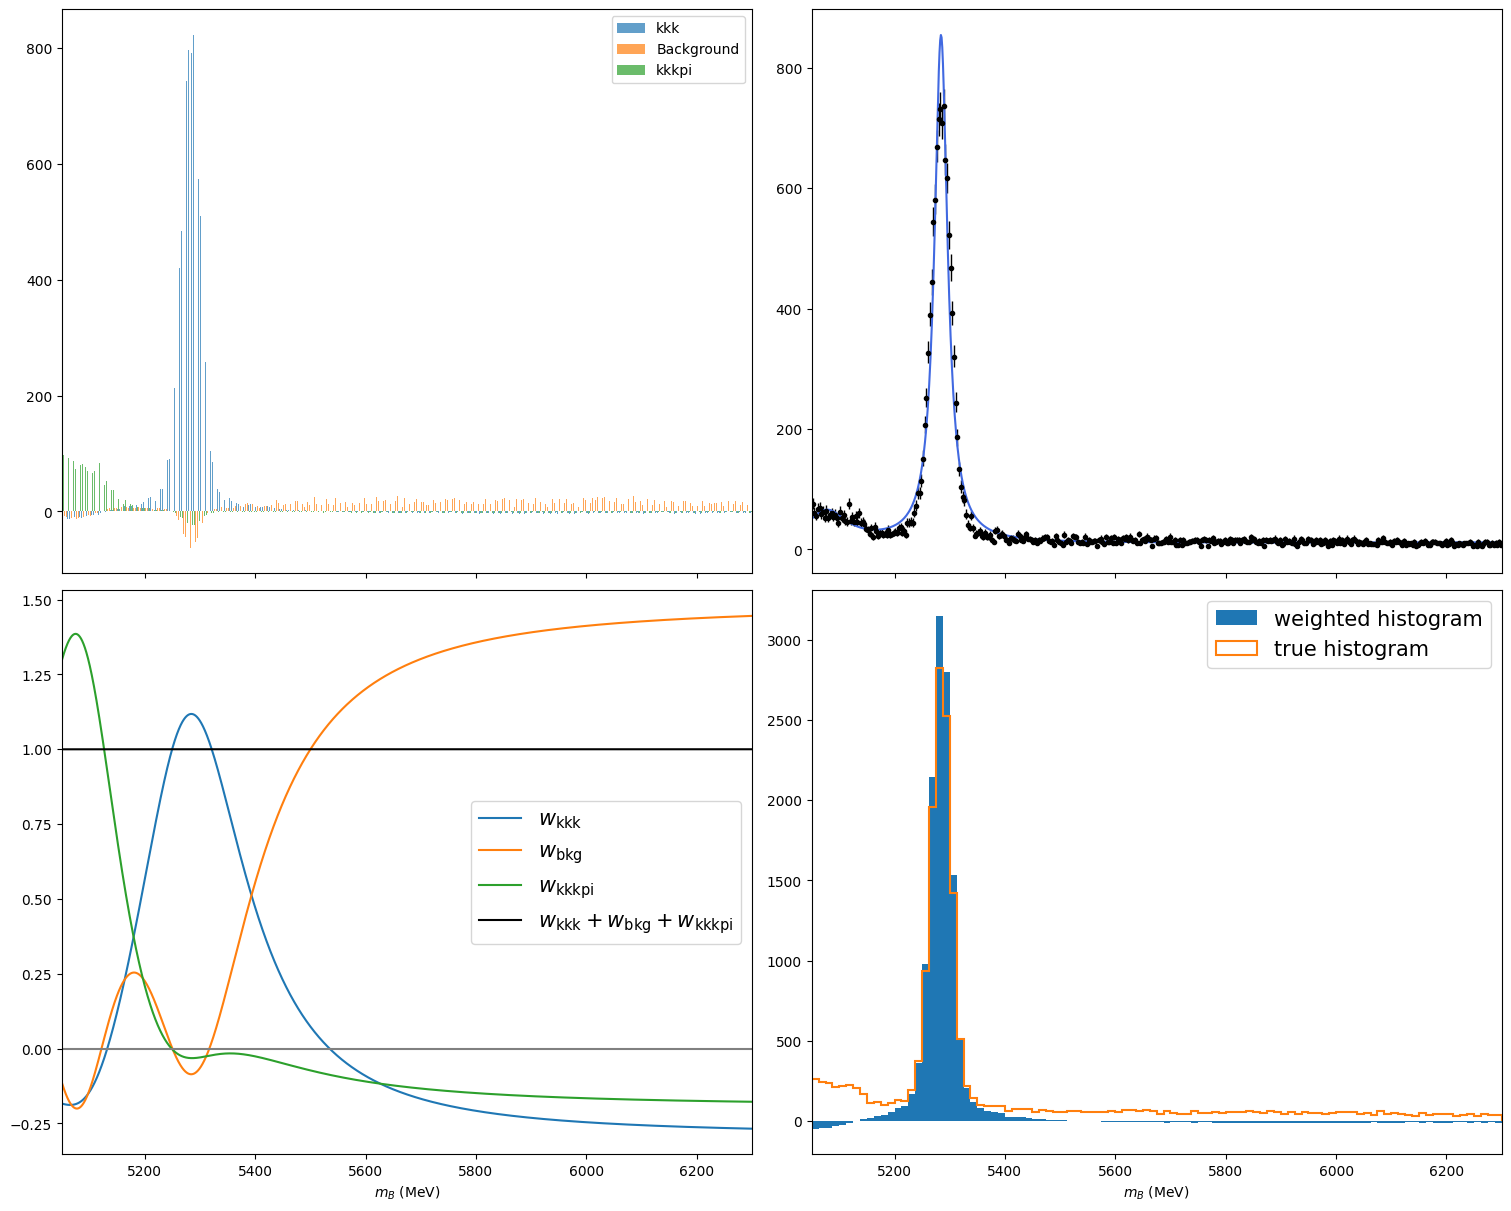

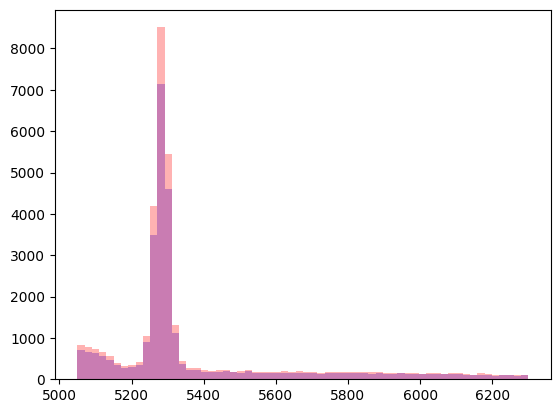

In [ ]:
# sPlot fitting 2x Cauchy + exponential
def sPlot2V1e(result_neg_unbinned_cauchy=result_neg_unbinned_cauchy,result_pos_unbinned_cauchy=result_pos_unbinned_cauchy):
    def cauchy(x, x0, gamma,N_s1):
        return N_s1 * (1/np.pi) * (gamma / ((x - x0)**2 + gamma**2))
    def exponential(x,lambda_,N_bkg):
        return -lambda_*np.exp(lambda_*x)

    def naive_weights(result_pos_unbinned,result_neg_unbinned,positive_B_mask,negative_B_mask):
        def probs(x,mean_signal,std_signal,lambda_,N_s1,N2,N_bkg,mean2,signal2):
            signal=cauchy(x,mean_signal,std_signal,N_s1)
            e=exponential(x,lambda_,N_bkg)
            kkkp=cauchy(x,mean2,signal2,N2)
            prob_signal=signal/(signal+e)
            prob_e=e/(signal+e)
            prob_kkkp=kkkp/(signal+e+kkkp)
            return prob_signal,prob_e,prob_kkkp
        def retrieving_vals(unbinned_array):
                mean_signal=unbinned_array['result'].floatParsFinal().find("mean1").getVal()
                std_signal=unbinned_array['result'].floatParsFinal().find("sigma1").getVal()
                lambda_=unbinned_array['result'].floatParsFinal().find("k").getVal()
                N_s1=unbinned_array['N_s1'].getVal()
                N2=unbinned_array['N2'].getVal()
                mean_signal_2=unbinned_array['result'].floatParsFinal().find("mean2").getVal()
                std_signal_2=unbinned_array['result'].floatParsFinal().find("sigma2").getVal()
                N_bkg=unbinned_array['N_bkg'].getVal()
                gamma1=unbinned_array['gamma1'].getVal()
                gamma2=unbinned_array['gamma2'].getVal()
                return mean_signal,std_signal,lambda_,N_s1,N2,N_bkg,mean_signal_2,std_signal_2
        neg_fits_vals=retrieving_vals(result_neg_unbinned)
        pos_fits_vals=retrieving_vals(result_pos_unbinned)
        naive_weights_signal_pos,_,_=probs(dalitz_plot_m_B[positive_B_mask],*pos_fits_vals)
        naive_weights_signal_neg,_,_=probs(dalitz_plot_m_B[negative_B_mask],*neg_fits_vals)
        return naive_weights_signal_pos,naive_weights_signal_neg
            # naive_weights_signal_pos,_,_=probs(dalitz_plot_m_B[positive_B_mask],mean_signal,std_signal,lambda_,N_s1,N2,N_bkg,mean_signal_2,std_signal_2)
            # naive_weights_signal_neg,_,_=probs(dalitz_plot_m_B[negative_B_mask],mean_signal,std_signal,lambda_,N_s1,N2,N_bkg,mean_signal_2,std_signal_2)
    naive_weights_signal_pos_cauchy,naive_weights_signal_neg_cauchy = naive_weights(result_pos_unbinned=result_pos_unbinned_cauchy,result_neg_unbinned=result_neg_unbinned_cauchy,positive_B_mask=positive_B_mask,negative_B_mask=negative_B_mask)
    fig,ax=plt.subplots(2,2,figsize=(15,12),layout='constrained',sharex=True)
    def filtering_with_random_numbers_naive(naive_weights_signal_pos,naive_weights_signal_neg):

        random_number=np.random.randn(len(dalitz_plot_m_B[positive_B_mask]))

        positive_mask_naive_signal= (random_number<naive_weights_signal_pos)

        random_number=np.random.randn(len(dalitz_plot_m_B[negative_B_mask]))

        negative_mask_naive_signal= (random_number<naive_weights_signal_neg)
        print(negative_mask_naive_signal)
        total_mask_naive_signal=np.zeros(len(dalitz_plot_m_B),dtype=bool)
        total_mask_naive_signal[positive_B_mask]=positive_mask_naive_signal
        total_mask_naive_signal[negative_B_mask]=negative_mask_naive_signal
        
        dalitz_plot_m_high_filtered=dalitz_plot_m_high[total_mask_naive_signal]
        dalitz_plot_m_low_filtered=dalitz_plot_m_low[total_mask_naive_signal]
        return dalitz_plot_m_high_filtered,dalitz_plot_m_low_filtered,total_mask_naive_signal
    dalitz_plot_m_high_filtered,dalitz_plot_m_low_filtered,mask=filtering_with_random_numbers_naive(naive_weights_signal_pos_cauchy,naive_weights_signal_neg_cauchy)
    total_naive_weighting_signal_cauchy=np.zeros(len(dalitz_plot_m_B))
    total_naive_weighting_signal_cauchy[positive_B_mask]=naive_weights_signal_pos_cauchy
    total_naive_weighting_signal_cauchy[negative_B_mask]=naive_weights_signal_neg_cauchy



    def manual_s_plot(result,data,ax,plotting=True):
        data_np = data
        
        obs = zfit.Space('mass', (5050, 6300))
        data_z_fit=zfit.Data.from_numpy(obs=obs,array=data_np)
        
        # Extract mean/sigma/lambda values from RooFit result
        res = result["result"].floatParsFinal()
        mean1_val  = res.find("mean1").getVal()
        sigma1_val = res.find("sigma1").getVal()
        mean2_val  = res.find("mean2").getVal()
        sigma2_val = res.find("sigma2").getVal()
        k_val      = res.find("k").getVal()

        # Extract yields
        N_s1_val  = res.find("N_s1").getVal()
        N2_val    = res.find("N2").getVal()
        N_bkg_val = res.find("N_bkg").getVal()

        # Build zfit parameters
        mean1  = zfit.Parameter("mean1", mean1_val)
        sigma1 = zfit.Parameter("sigma1", sigma1_val)
        mean2  = zfit.Parameter("mean2", mean2_val)
        sigma2 = zfit.Parameter("sigma2", sigma2_val)
        lam    = zfit.Parameter("lambda", k_val)

        sig_yield = zfit.Parameter("N_s1", N_s1_val)
        cut_yield = zfit.Parameter("N2", N2_val)
        bkg_yield = zfit.Parameter("N_bkg", N_bkg_val)

        # Build PDFs
        cauchy1 = zfit.pdf.Cauchy(obs=obs, m=mean1, gamma=sigma1)
        cauchy2 = zfit.pdf.Cauchy(obs=obs, m=mean2, gamma=sigma2)
        expo   = zfit.pdf.Exponential(obs=obs, lam=lam)

        # Extended PDFs
        ext_cauchy1 = cauchy1.create_extended(sig_yield)
        ext_cauchy2 = cauchy2.create_extended(cut_yield)
        ext_expo   = expo.create_extended(bkg_yield)

        # Combined model
        model = zfit.pdf.SumPDF([ext_cauchy1, ext_cauchy2, ext_expo])

        pdf_values = model.pdf(data_z_fit)
        print(f"Any NaN in PDF: {np.any(np.isnan(pdf_values.numpy()))}")
        print(f"Any zero in PDF: {np.any(pdf_values.numpy() == 0)}")
        print(f"Min PDF value: {pdf_values.numpy().min()}")


        # # Signal distributions.
        # nsig_sw = 20000
        # np_sig_m_sw = gauss1.sample(nsig_sw).numpy().reshape(-1,)
        # np_sig_t_sw = np.random.exponential(size=nsig_sw, scale=1)

        # # Background distributions.
        # nbkg_sw = 20000
        # np_bkg_m_sw = expo.sample(nbkg_sw).numpy().reshape(-1,)
        # np_bkg_t_sw = np.random.normal(size=nbkg_sw, loc=2.0, scale=2.5)

        # ax[0][0].hist([np_bkg_m_sw, np_sig_m_sw], bins=100, stacked=True, label=("background", "signal"), alpha=.7)
        
        counts, bin_edges = np.histogram(data_np, bins=400)
        
        data_sw = zfit.Data.from_numpy(obs=obs, array=data_np)
        nll = zfit.loss.ExtendedUnbinnedNLL(model, data_sw)  # data_zfit = your actual data

        result=zfit.minimize.Minuit(use_minuit_grad=True).minimize(nll)

        weights = compute_sweights(model, data_sw)




        sorter = data_np.argsort()

        

        if plotting:
            mplhep.histplot(counts, bins=bin_edges, histtype="errorbar", yerr=True,
                        label="Data", ax=ax[0][1], color="black")
            bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
            binwidth = np.diff(bin_edges)[0]

            x = np.linspace(5050, 6300, num=1000)  # or np.linspace

            # Line plots of the total pdf and the sub-pdfs.
            y = model.ext_pdf(x) * binwidth
            ax[0][1].plot(x, y, label="total", color="royalblue")


            # Individual components scaled to yield per bin
            signal_pdf_vals = ext_cauchy1.ext_pdf(x) * binwidth
            cut_pdf_vals    = ext_cauchy2.ext_pdf(x) * binwidth
            bkg_pdf_vals    = ext_expo.ext_pdf(x) * binwidth


            ax[0][0].hist(
            [data_np[sorter], data_np[sorter],data_np[sorter]],  # same data, weights will separate components
            bins=bin_edges,
            weights=[weights[sig_yield][sorter], weights[bkg_yield][sorter], weights[cut_yield][sorter]],
            stacked=False,
            label=["kkk", "Background", "kkkpi"],
            alpha=0.7)
            ax[0][0].legend()

        

            ax[1][0].plot(data_np[sorter], weights[sig_yield][sorter], label="$w_\\mathrm{kkk}$")
            ax[1][0].plot(data_np[sorter], weights[bkg_yield][sorter], label="$w_\\mathrm{bkg}$")
            ax[1][0].plot(data_np[sorter], weights[cut_yield][sorter], label="$w_\\mathrm{kkkpi}$")
            ax[1][0].plot(data_np[sorter], weights[sig_yield][sorter] + weights[bkg_yield][sorter] + weights[cut_yield][sorter],
                        "-k", label="$w_\\mathrm{kkk} + w_\\mathrm{bkg} + w_\\mathrm{kkkpi}$")
            ax[1][0].axhline(0, color="0.5")
            ax[1][0].legend(fontsize=15)
            ax[1][0].set_xlim(5050, 6300)

            ax[1][1].hist(data_np,bins=100,weights=weights[sig_yield],label='weighted histogram')
            ax[1][1].hist(data_np,bins=100,histtype="step",lw=1.5,label='true histogram')
            ax[1][1].legend(fontsize=15)
            ax[1][0].set_xlabel("$m_B$ (MeV)")
            ax[1][1].set_xlabel("$m_B$ (MeV)")
        
        return weights[sig_yield]
    weights_pos_cauchy=manual_s_plot(result_pos_unbinned_cauchy,dalitz_plot_m_B[positive_B_mask],ax,plotting=True)
    weights_neg_cauchy=manual_s_plot(result_neg_unbinned_cauchy,dalitz_plot_m_B[negative_B_mask],ax,plotting=False)

    fig,ax=plt.subplots(1)
    ax.hist(dalitz_plot_m_B[mask],bins=int((max(dalitz_plot_m_B[mask])-min(dalitz_plot_m_B[mask]))/20),color='blue',alpha=0.3)
    ax.hist(dalitz_plot_m_B,bins=int((max(dalitz_plot_m_B)-min(dalitz_plot_m_B))/20),color='red',alpha=0.3)
    return weights_pos_cauchy,weights_neg_cauchy
weights_pos_cauchy, weights_neg_cauchy = sPlot2C1e()
    # plt.plot(dalitz_plot_m_B,total_naive_weighting_signal,color='k')
    # plt.plot(dalitz_plot_m_B_side_cuts,values_e)
    # plt.show()




### Assymetry and Dalitz Plots

In [13]:
def Asymmetry(N_pos,N_neg):
    return (N_neg-N_pos)/(N_neg+N_pos)
def Asymmetry_uncertainty_with_N(N_pos,N_pos_err,N_neg,N_neg_err):
    # return np.sqrt((4/(N_pos+N_neg)**4)*(N_neg**2*N_pos_err**2+N_pos**2*N_neg_err**2))
    return ((N_neg_err/(N_neg+N_pos)**4)**2)+(N_pos_err/(N_neg+N_pos)**4)**2
def Asymmetry_uncertainty_with_A(N_pos,N_neg,A):
    return np.sqrt((1-A**2)/(N_neg+N_pos))
A=Asymmetry(result_pos_unbinned['result'].floatParsFinal().find("N_s1").getVal(),result_neg_unbinned['result'].floatParsFinal().find("N_s1").getVal())
print("assymetry with root= ",A)
print("uncertainty using A= ",Asymmetry_uncertainty_with_A(result_pos_unbinned['result'].floatParsFinal().find("N_s1").getVal(),result_neg_unbinned['result'].floatParsFinal().find("N_s1").getVal(),A))
nll_pos_value = result_pos_unbinned['result'].minNll() 

assymetry with root=  -0.05343159439385626
uncertainty using A=  0.007132540131839297


In [14]:
def dalitz_plots(dalitz_plot_m_high,dalitz_plot_m_low,total_sig_weights,name):
    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 12),layout='constrained',sharex=True)
    fig.subplots_adjust(wspace=0.3) # increase horizontal space between plots

    

    # This plots two 1D-histograms.
    # The color is changed automatically, the styles are set by hand
    # keep hold of the pT histogram data for fitting later
    print('Plotting 1D histogram')
    # values_m_B,bins_m_B,patches_m_B = ax[0].hist(m_B_all, bins = 200, range = [5000, 6000],histtype='step',label='$m_{B}$')
    # values_m_R12,bins_m_R12,patches_m_R12 = ax[0].hist(m_high_all, bins = 200, range = [0, 6000],histtype='step',label='$m_{max}$')
    # values_m_R13,bins_m_R13,patches_m_R13 = ax[0].hist(m_low_all, bins = 200, range = [0, 6000],histtype='step',label='$m_{min}$')

    values_m_high,bins_m_high,patches_m_high=ax[0][0].hist((dalitz_plot_m_high**2)/1000000,bins=300,histtype='step',weights=total_sig_weights,label='$m_{max}$')
    values_m_low,bins_m_low,patches_m_low=ax[0][0].hist((dalitz_plot_m_low**2)/1000000,bins=300,histtype='step',weights=total_sig_weights,label='$m_{min}$')
    # ax[0].hist(dalitz_plot_m_B_filtered**2,bins=300,histtype='step',label='$m_B$')


    # values_m_B,bins_m_B,patches_m_B = ax[2].hist(m_B_all, bins = 200, weights=(1/m_B_all_uncertainties),range = [5000, 6000],histtype='step',label='$m_{B}$')
    # values_m_R12,bins_m_R12,patches_m_R12 = ax[2].hist(m_high_all, bins = 200,weights=(1/m_high_all_uncertainties), range = [0, 6000],histtype='step',label='$m_{max}$')
    # values_m_R13,bins_m_R13,patches_m_R13 = ax[3].hist(m_low_all, bins = 200,weights=(1/m_low_all_uncertainties), range = [0, 6000],histtype='step',label='$m_{min}$',color='g')

    # # phi strange-antistrange
    # ax[0].axvline(1019.461,color='red')
    # #f'_2 - mainly strange-anti-strange with some up-anti-up and down-antidown
    # ax[0].axvline(1512,color='red')
    # #eta - even mix of up-anti-up, down-antidown and strange-antistrange
    # ax[0].axvline(1475,color='red')
    # #rho - mainly up-anti-up and down-antidown
    # ax[0].axvline(1450,color='red')
    # # D_0 charm antiup
    # ax[0].axvline(1864.84,color='red')

    # # 2-3 GeV region is mainly comprised of excited light meson states.

    # # J/psi charm-anticharm
    # ax[0].axvline(3096.9,color='red')
    # #chi_c0 charm-anticharm
    # ax[0].axvline(3414.71,color='red')
    # # Charmonium (excited) states) and tetra quark candidates in the region of 4GeV - 4.5 GeV
    # ax[0].axvline(4100,color='red')

    # #slight peak before could be from particle misidentification from choosing the wrong kaon candidate.

    # # B meson
    # ax[0].axvline(5279,color='k',linestyle='--')


    # peaks,_=scipy.signal.find_peaks(values_m_B,height=25)
    # widths,width_heights,pos_left,pos_right=scipy.signal.peak_widths(values_m_B,peaks,rel_height=0.5)
    # int_pos_right=int(np.floor(pos_right[0]))
    # int_pos_left=int(np.floor(pos_left[0]))
    # print(bins_m_B[peaks],values_m_B[peaks])
    # print((m_B.max()-m_B.min())/2000)
    # ax.scatter(bins_m_B[peaks],values_m_B[peaks],color='red')
    # ax.hlines(0.5*values_m_B[peaks],bins_m_B[int_pos_left],bins_m_B[int_pos_right],color='red')
    #ax[0].hist(pZ, bins = 200, range = [0, 100000],histtype='stepfilled',alpha=0.3,label='$p_{z}$')

    bin_width=np.diff(bins_m_high)[0]*10**6
    print(bin_width)
    ax[1][0].set_xlabel('$m_{lower}$ Meson Invariant Mass squared in $GeV^2$')
    ax[0][0].set_ylabel(f'Entries per {int(bin_width)} $MeV^2$')
    ax[0][0].set_xlabel('Invariant Mass squared in $GeV^2$')
    ax[0][0].legend()
    h2d_weights=ax[1][0].hist2d((dalitz_plot_m_low**2)/1000000,(dalitz_plot_m_high**2)/1000000,bins=300,weights=total_sig_weights,norm=colors.LogNorm(vmin=1,vmax=100))
    ax[1][0].set_ylabel('$m_{higher}$ Invariant Mass squared in $GeV^2$')

    values_m_high,bins_m_high,patches_m_high=ax[0][1].hist((dalitz_plot_m_high**2)/1000000,bins=300,histtype='step',label='$m_{max}$')
    values_m_low,bins_m_low,patches_m_low=ax[0][1].hist((dalitz_plot_m_low**2)/1000000,bins=300,histtype='step',label='$m_{min}$')
    ax[1][1].set_xlabel('$m_{lower}$ Meson Invariant Mass squared in $GeV^2$')
    ax[0][1].set_ylabel(f'Entries per {int(bin_width)} $MeV^2$')
    ax[0][1].set_xlabel('Invariant Mass squared in $GeV^2$')
    ax[0][1].legend()
    ax[0][0].set_ylim(0,3000)
    h2d_no_weights=ax[1][1].hist2d((dalitz_plot_m_low**2)/1000000,(dalitz_plot_m_high**2)/1000000,bins=300,norm=colors.LogNorm(vmin=1,vmax=100))
    ax[1][1].set_ylabel('$m_{higher}$ Invariant Mass squared in $GeV^2$')

    fig.suptitle(name)
    fig.colorbar(h2d_weights[3],ax=ax[1][0]) 
    cbar=fig.colorbar(h2d_no_weights[3],ax=ax[1][1],) 
    return h2d_weights

corr_high = np.corrcoef(dalitz_plot_m_B, dalitz_plot_m_high)[0,1]
corr_low = np.corrcoef(dalitz_plot_m_B, dalitz_plot_m_low)[0,1]
spearman_corr_high=scipy.stats.spearmanr(dalitz_plot_m_B, dalitz_plot_m_high)
spearman_corr_low=scipy.stats.spearmanr(dalitz_plot_m_B, dalitz_plot_m_low)

print("Correlation coefficient:", corr_high,corr_low)
print("Spearman correlation: ", spearman_corr_high.statistic, spearman_corr_low.statistic)
print("Spearman p-value:     ", spearman_corr_high.pvalue, spearman_corr_low.pvalue)
print(len(weights_neg))
print(len(weights_pos))
def total_weights(weights_pos,weights_neg,dalitz_plot_m_B=dalitz_plot_m_B,negative_B_mask=negative_B_mask,positive_B_mask=positive_B_mask):
    total_sig_weights=np.zeros(len(dalitz_plot_m_B))
    total_sig_weights[positive_B_mask]=weights_pos
    total_sig_weights[negative_B_mask]=weights_neg
    return total_sig_weights
total_sig_weights_2G1e = total_weights(weights_pos=weights_pos, weights_neg=weights_neg)
total_sig_weights_2C1e = total_weights(weights_pos=weights_pos_cauchy, weights_neg=weights_neg_cauchy)
weighted_dalitz_plot=dalitz_plots(dalitz_plot_m_high,dalitz_plot_m_low,total_sig_weights,"Splot vs no weightings")
dalitz_plots(dalitz_plot_m_high,dalitz_plot_m_low,total_naive_weighting_signal,"naive sideband vs weightings")


Correlation coefficient: 0.3384689408460433 0.23197670033502837
Spearman correlation:  0.2439766891617487 0.1592969192539332
Spearman p-value:      0.0 9.206633190758092e-192
16270
17679


NameError: name 'total_sig_weights' is not defined

1


/var/folders/t5/81d1csyx7gj3vdvt48vcs2v40000gn/T/ipykernel_8936/937416762.py:20: RuntimeWarning: invalid value encountered in divide
  A = (N1 - alpha*N2) / (N1 + alpha*N2)
/var/folders/t5/81d1csyx7gj3vdvt48vcs2v40000gn/T/ipykernel_8936/937416762.py:23: RuntimeWarning: invalid value encountered in sqrt
  sigma_A = np.sqrt((1-A**2)/(N1+N2))
/var/folders/t5/81d1csyx7gj3vdvt48vcs2v40000gn/T/ipykernel_8936/937416762.py:27: RuntimeWarning: invalid value encountered in sqrt
  S_CP = (N1 - alpha*N2) / np.sqrt(N1 + (alpha**2)*N2)
/var/folders/t5/81d1csyx7gj3vdvt48vcs2v40000gn/T/ipykernel_8936/937416762.py:27: RuntimeWarning: invalid value encountered in divide
  S_CP = (N1 - alpha*N2) / np.sqrt(N1 + (alpha**2)*N2)


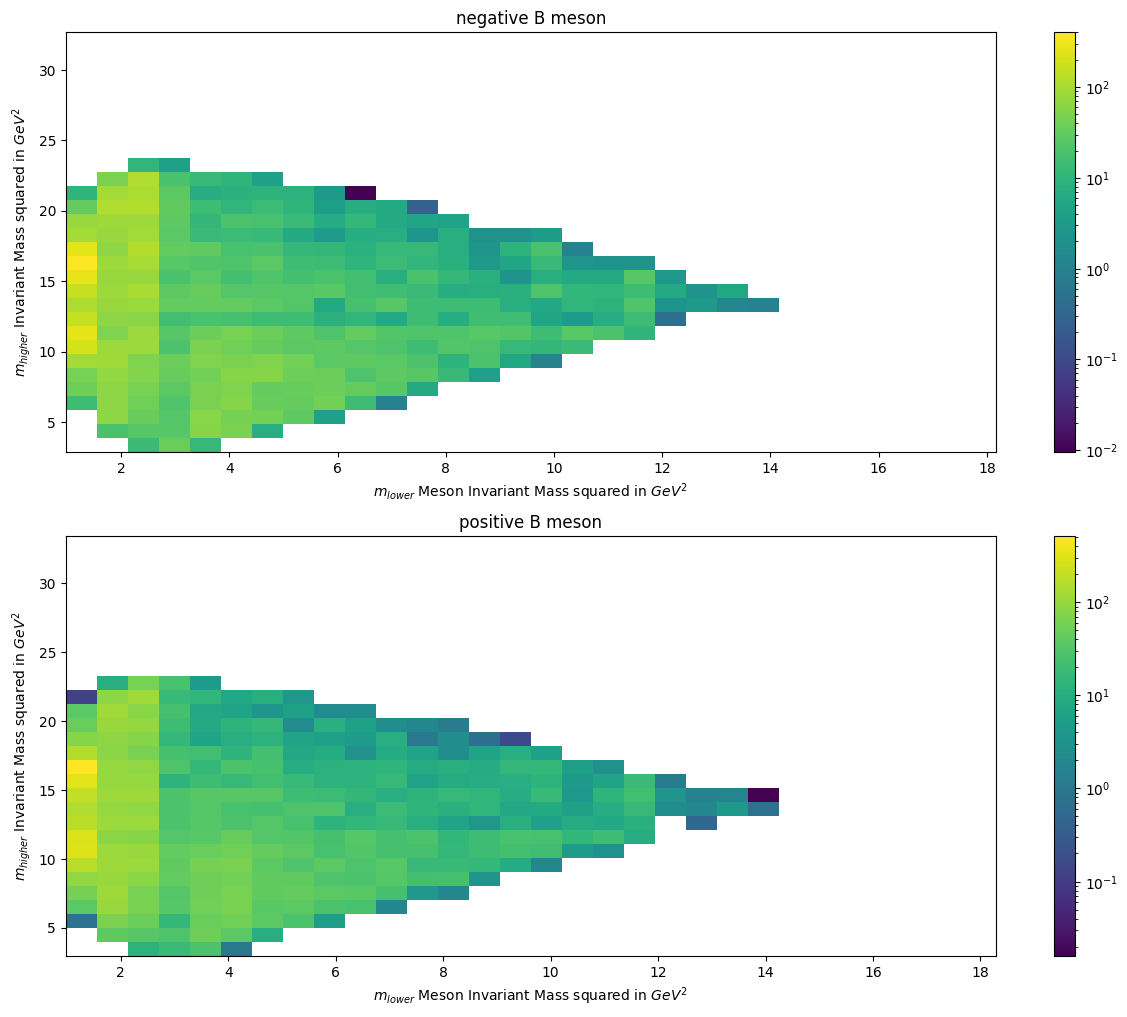

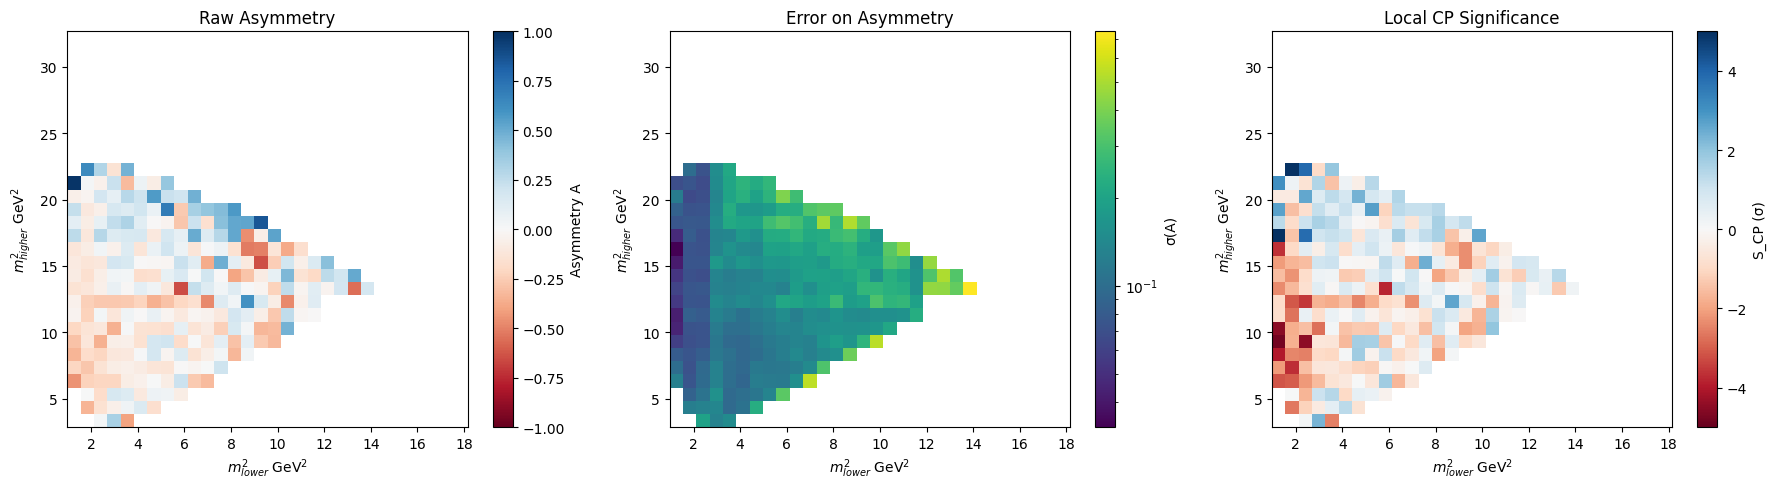

Min counts per bin: 1.8
Mean counts per bin: 71.0
0.9060137946916057


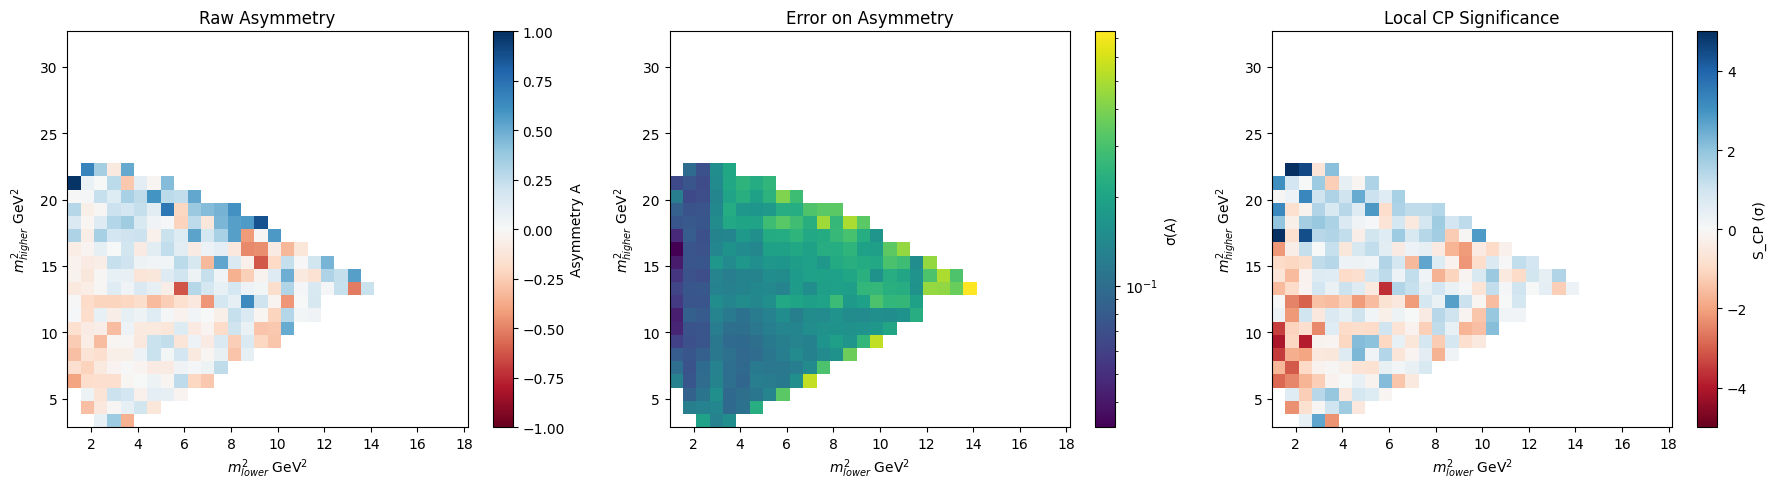

Min counts per bin: 1.8
Mean counts per bin: 71.0


In [ ]:
fig,ax=plt.subplots(2,figsize=(15,12))
ax[0].set_xlabel('$m_{lower}$ Meson Invariant Mass squared in $GeV^2$')
h2d_weights_negative=ax[0].hist2d((dalitz_plot_m_low[negative_B_mask]**2)/1000000,(dalitz_plot_m_high[negative_B_mask]**2)/1000000,bins=30,weights=weights_neg,norm=colors.LogNorm())
ax[0].set_ylabel('$m_{higher}$ Invariant Mass squared in $GeV^2$')
ax[0].set_title('negative B meson')
fig.colorbar(h2d_weights_negative[3], ax=ax[0])



ax[1].set_xlabel('$m_{lower}$ Meson Invariant Mass squared in $GeV^2$')
h2d_weights_positive=ax[1].hist2d((dalitz_plot_m_low[positive_B_mask]**2)/1000000,(dalitz_plot_m_high[positive_B_mask]**2)/1000000,bins=30,weights=weights_pos,norm=colors.LogNorm())
ax[1].set_ylabel('$m_{higher}$ Invariant Mass squared in $GeV^2$')
ax[1].set_title('positive B meson')
fig.colorbar(h2d_weights_positive[3], ax=ax[1])


def asymmetry_and_error(N1, N2,alpha):
    print(alpha)
    # Raw asymmetry
    A = (N1 - alpha*N2) / (N1 + alpha*N2)
    
    # Error on asymmetry via Poisson error propagation
    sigma_A = np.sqrt((1-A**2)/(N1+N2))
    
    
    # Significance (S_CP from before)
    S_CP = (N1 - alpha*N2) / np.sqrt(N1 + (alpha**2)*N2)
    
    return A, sigma_A, S_CP

xedges = h2d_weights_negative[1]
yedges = h2d_weights_negative[2]

def dalitz_asymmetry(alpha=1):

    total_counts = h2d_weights_negative[0] + h2d_weights_positive[0]
    A,sigma_A,S_CP = asymmetry_and_error(h2d_weights_negative[0], h2d_weights_positive[0],alpha)
    min_counts = np.minimum(h2d_weights_negative[0], h2d_weights_positive[0])
    mask=min_counts>0
    A=np.where(mask,A,np.nan)
    sigma_A=np.where(mask,sigma_A,np.nan)
    S_CP=np.where(mask,S_CP,np.nan)



    fig2, ax2 = plt.subplots(1, 3, figsize=(18, 5))

    p1 = ax2[0].pcolormesh(xedges, yedges, A.T, cmap='RdBu', vmin=-1, vmax=1)
    fig2.colorbar(p1, ax=ax2[0], label='Asymmetry A')
    ax2[0].set_title('Raw Asymmetry')


    p2 = ax2[1].pcolormesh(xedges, yedges, sigma_A.T, cmap='viridis',norm=colors.LogNorm())
    fig2.colorbar(p2, ax=ax2[1], label='σ(A)')
    ax2[1].set_title('Error on Asymmetry')

    p3 = ax2[2].pcolormesh(xedges, yedges, S_CP.T, cmap='RdBu', vmin=-5, vmax=5)
    fig2.colorbar(p3, ax=ax2[2], label='S_CP (σ)')
    ax2[2].set_title('Local CP Significance')

    for a in ax2:
        a.set_xlabel('$m_{lower}^2$ GeV$^2$')
        a.set_ylabel('$m_{higher}^2$ GeV$^2$')

    plt.tight_layout()
    plt.show()

    print(f"Min counts per bin: {(h2d_weights_negative[0] + h2d_weights_positive[0])[mask].min():.1f}")
    print(f"Mean counts per bin: {(h2d_weights_negative[0] + h2d_weights_positive[0])[mask].mean():.1f}")

    return A,sigma_A,S_CP,mask

N1,N2=h2d_weights_negative[0], h2d_weights_positive[0]
alpha = np.sum(N1) / np.sum(N2)
_,_,S_CP_no_alpha,mask_no_alpha =dalitz_asymmetry()
A,sigma_A,S_CP,mask=dalitz_asymmetry(alpha)





